<a href="https://colab.research.google.com/github/SameerPasha565/Air-pollution-analysis/blob/main/Prac1Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Air Quality Analysis of Beijing(2013-2017)**

**Overview**

Air pollution is a critical environmental challenge, with particulate matter (PM 2.5) posing significant risk to cardiovascular and respiratory health. This project analyses hourly air quality and meteorological data from four monitoring stations in Beijing, China, covering the period from **1 March 2013 to 28 February 2017**.

**Objectives**

The 4 selected stations are:
- **Urban:** Dongsi, Gucheng
- **Suburban:** Changping, Huairou

This selection follows **Xu & Zhang (2020)**, who classified these stations
based on population density and geographic location within Beijing.

Following the findings of Xu & Zhang(2020), this analysis aim to:
1. Investigate the **Spatial Variability** between urban (**Dongsi, Gucheng**) and suburban (**Changping, Huairou**) stations.
2. Analyze **Temporal Trends**, between the "Heating Season" (Nov-Mar) and "Non- Heating Season".
3. Evaluate the correlation between meteorological factors (Temperature, Pressure) and pollutant concentrations.
4. Build a **machine learning model** to predict PM2.5 levels.
5. Develop an **interactive GUI application** for data exploration and forecasting.

###**Git Cloning**
The code, data, and notebook are version-controlled using **GitHub**.

In [2]:
! git config --global user.name "sameerpasha565"

In [4]:
! git config --global user.email "sameerpasha565@gmail.com"

In [3]:
username = "sameerpasha565"
repo = "Air-pollution-analysis"

In [5]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'Air-pollution-analysis'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 26 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 6.21 MiB | 5.34 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [6]:
%cd {repo}

/content/Air-pollution-analysis


###**Importing the necessary Libraries:**

In [7]:
# Standard Libraries
import numpy as np
import pandas as pd
import calendar

# Visualisation Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Plotly Libraries
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

# File Handling
import glob
import os

import warnings
warnings.filterwarnings('ignore')

---

## **1: Data Selection & Handling**

### **Station Justification**

Following **Xu & Zhang (2020)** and **Yao et al. (2015)**, Beijing's monitoring stations can be classified as either urban (inner) or suburban (outer) based on their geographic location and surrounding land use:

|Station | Type | Justification |
|---|---|---|
| **Dongsi** | Urban | Located in Dongcheng, a densely populated central district with heavy traffic |
| **Gucheng** | Urban | Located in Shijingshan district, a major urban industrial zone |
| **Changping** | Suburban | Located in northern Beijing's Changping district, lower population density |
| **Huairou** | Suburban | Located in the mountainous northern outskirts of Beijing, mostly rural |

These stations were chosen because they provide a balanced data of the wider monitoring network. **Dongsi** is located in a dense central urban area and is strongly influenced by high traffic activity, making it a suitable station for representing pollution from road transport and city-centre emissions. **Gucheng** is also an urban station, but it is more suitable for capturing pollution influenced by both urban activity and industrial surroundings, which adds variety to the urban sample. Together, Dongsi and Gucheng provide two different but complementary urban pollution environments.

For the suburban group, **Changping** and **Huairou** were selected because they represent lower-density outer areas with less traffic and less industrial activity compared with the city centre. Their mean PM2.5 values, **63 µg/m³** for Changping and **62 µg/m³** for Huairou, are also close to each other, which makes them a stable and comparable suburban pair. This makes them more suitable than **Shunyi**, whose higher mean value of **70 µg/m³** suggests stronger urban influence, and more balanced than **Dingling**, which is the lowest and therefore slightly more extreme suburban case.

This combination of the dataset captures both traffic-dominated and industrial-urban pollution patterns, as well as cleaner outer-area conditions, making the subset more useful for preprocessing, EDA, and model building.

In [ ]:
StationData_files = glob.glob("*20170228.csv")

###**Merging the Urban and Suburban station Data**

In [ ]:
All_Station_data = []

for file_name in StationData_files:
    city_df = pd.read_csv(file_name)

    All_Station_data.append(city_df)

    print(f"Loaded: {file_name}")

combined_data = pd.concat(All_Station_data, ignore_index=True)

combined_data.to_csv("All_Station_data_combined.csv", index=False)

print(f"SUCCESS: Combined {len(All_Station_data)} files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: All_Station_data_combined.csv")

Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
SUCCESS: Combined 4 files into one file with 140256 total rows
The combined file is saved as: All_Station_data_combined.csv


## **Exploratory Data Analysis**

This section is structured as follows:
- **2.1 Data Understanding** — basic inspection
- **2.2 Data Preprocessing** — cleaning and feature engineering
- **2.3 Statistical & Visual Analysis** — plots, correlations, and inferences

## **2.1 Data Understanding**

We begin by loading the merged dataset and inspecting its basic properties — shape, column names, data types, missing values, and statistical summaries.

In [8]:
df= pd.read_csv('All_Station_data_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,14.0,58.0,4.0,19.0,500.0,56.0,12.8,1009.9,-17.0,0.0,NNW,3.1,Gucheng
140252,35061,2017,2,28,20,27.0,83.0,6.0,60.0,700.0,26.0,11.1,1010.4,-15.5,0.0,NW,1.9,Gucheng
140253,35062,2017,2,28,21,22.0,37.0,7.0,52.0,600.0,27.0,10.5,1010.8,-15.9,0.0,N,2.3,Gucheng
140254,35063,2017,2,28,22,9.0,23.0,3.0,13.0,400.0,57.0,8.9,1010.9,-14.9,0.0,NE,1.6,Gucheng


In [ ]:
df.shape

(140256, 18)

### **Inference**

The combined dataset contains **140,256 rows** and **18 columns**, representing hourly measurements across 4 stations from March 2013 to February 2017 (approximately 4 years). Each row captures one hour of pollutant and meteorological readings at a specific station.

In [ ]:
print("Data Types Summary:")
print(df.info())
print(f"\nTotal columns   : {df.shape[1]}")
print(f"Total rows      : {df.shape[0]}")
print(f"Integer columns : {len(df.select_dtypes('int64').columns)}")
print(f"Float columns   : {len(df.select_dtypes('float64').columns)}")
print(f"Object columns  : {len(df.select_dtypes('object').columns)}")

Data Types Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137133 non-null  float64
 6   PM10     137963 non-null  float64
 7   SO2      137478 non-null  float64
 8   NO2      135681 non-null  float64
 9   CO       132715 non-null  float64
 10  O3       137108 non-null  float64
 11  TEMP     140081 non-null  float64
 12  PRES     140083 non-null  float64
 13  DEWP     140079 non-null  float64
 14  RAIN     140087 non-null  float64
 15  wd       139577 non-null  object 
 16  WSPM     140108 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 19.3+ MB
None

Total columns   : 1

### Inference

The dataset contains **5 integer columns** (No, year, month, day, hour), **11 float columns** (all pollutants and meteorological variables), and **2 object columns** (wind direction `wd` and `station`).

| Column | Description |
|---|---|
| No | Row index |
| year, month, day, hour | Timestamp components |
| PM2.5 | Fine particulate matter < 2.5 µm (µg/m³) |
| PM10 | Coarse particulate matter < 10 µm (µg/m³) |
| SO2 | Sulphur dioxide (µg/m³) |
| NO2 | Nitrogen dioxide (µg/m³) |
| CO | Carbon monoxide (µg/m³) |
| O3 | Ozone (µg/m³) |
| TEMP | Temperature (°C) |
| PRES | Atmospheric pressure (hPa) |
| DEWP | Dew point temperature (°C) |
| RAIN | Rainfall (mm) |
| wd | Wind direction (categorical) |
| WSPM | Wind speed (m/s) |
| station | Monitoring station name |

### **Station wise statistics**

In [33]:
display(df.groupby("station")[["PM2.5", "PM10"]].describe())
display(df.groupby("station")[["CO", "NO2"]].describe())
display(df.groupby("station")[["TEMP", "WSPM"]].describe())


PM2.5                                                        \
             count       mean        std  min   25%   50%     75%    max   
station                                                                    
Changping  34290.0  71.099743  72.326926  2.0  18.0  46.0  100.00  882.0   
Dongsi     34314.0  86.194297  86.575127  3.0  22.0  61.0  119.00  737.0   
Gucheng    34418.0  83.852089  82.796445  2.0  24.0  60.0  115.75  770.0   
Huairou    34111.0  69.626367  71.224916  2.0  17.0  47.0   98.00  762.0   

              PM10                                                        
             count        mean        std  min   25%   50%    75%    max  
station                                                                   
Changping  34482.0   94.657871  83.441738  2.0  34.0  72.0  131.0  999.0  
Dongsi     34511.0  110.336742  98.219860  2.0  38.0  86.0  151.0  955.0  
Gucheng    34683.0  118.861978  96.742626  2.0  45.0  99.0  167.0  994.0  
Huairou    34287.0   91.482690  83.289578  2.0  28.0  69.0  131.0  993.0

CO                                                          \
             count         mean          std    min    25%     50%     75%   
station                                                                      
Changping  33543.0  1152.301345  1103.056282  100.0  500.0   800.0  1400.0   
Dongsi     31867.0  1330.069131  1191.305887  100.0  600.0  1000.0  1700.0   
Gucheng    33663.0  1323.974423  1208.957772  100.0  600.0   900.0  1600.0   
Huairou    33642.0  1022.554545   898.738241  100.0  400.0   800.0  1300.0   

                        NO2                                            \
               max    count       mean        std     min   25%   50%   
station                                                                 
Changping  10000.0  34397.0  44.182086  29.519796  1.8477  22.0  36.0   
Dongsi     10000.0  33463.0  53.699443  33.959230  2.0000  27.0  47.0   
Gucheng    10000.0  34396.0  55.871075  36.473860  2.0000  26.0  50.0   
Huairou    10000.0  33425.0  32.497250  26.489531  1.0265  12.0  25.0   

                           
               75%    max  
station                    
Changping  60.3582  226.0  
Dongsi     73.0000  258.0  
Gucheng    79.0000  276.0  
Huairou    46.0000  231.0

TEMP                                                     \
             count       mean        std   min  25%   50%   75%   max   
station                                                                 
Changping  35011.0  13.686111  11.365313 -16.6  3.4  14.7  23.3  41.4   
Dongsi     35044.0  13.671490  11.458418 -16.8  3.1  14.6  23.5  41.1   
Gucheng    35013.0  13.864524  11.292857 -15.6  3.6  14.8  23.5  41.6   
Huairou    35013.0  12.445426  11.751103 -19.9  2.1  13.6  22.3  40.3   

              WSPM                                                
             count      mean       std  min  25%  50%  75%   max  
station                                                           
Changping  35021.0  1.853836  1.309808  0.0  1.0  1.5  2.3  10.0  
Dongsi     35050.0  1.860785  1.280368  0.0  1.0  1.5  2.4  10.5  
Gucheng    35022.0  1.343310  1.151064  0.0  0.6  1.0  1.8  12.0  
Huairou    35015.0  1.652021  1.199143  0.0  0.9  1.3  2.0  12.9

### **Inference from Station-wise Statistics**

The descriptive statistics reveal a clear spatial differentiation in air quality across the four monitoring stations. By comparing the mean concentrations of key pollutants, we can observe distinct patterns that align with the urban and suburban classifications of the sites:

*   **Pollutant Intensity:** The urban stations, **Dongsi** and **Gucheng**, consistently record the highest mean concentrations for particulate matter and traffic-related gases. **Dongsi** exhibits a mean PM2.5 level of **86.19 µg/m³**, while **Gucheng** shows a mean of **83.85 µg/m³**. In contrast, the suburban stations, **Changping** and **Huairou**, show lower averages, with PM2.5 levels of **71.10 µg/m³** and **69.63 µg/m³**, respectively. This gradient is also mirrored in **PM10, NO2,** and **CO** levels, confirming that urban sites are exposed to a more intense pollution burden.

*   **Traffic and Combustion Indicators:** The gas-phase pollutants provide further insight into the drivers of this pollution. **NO2** mean concentrations are significantly higher at the urban sites—**Gucheng (55.87 µg/m³)** and **Dongsi (53.70 µg/m³)**—compared to **Huairou (32.50 µg/m³)**. This is a strong indicator of heavier traffic and combustion emissions in Beijing’s core urban districts. Similarly, **CO** levels follow this urban–suburban split, reinforcing the impact of localized anthropogenic activities.

*   **Meteorological Context:** While pollutant levels vary, the meteorological indicators—**TEMP** and **WSPM** (Wind Speed)—remain relatively stable across the city. The mean temperature is roughly **13°C** across most sites, though **Huairou** shows a slightly cooler mean of **12.45°C**. Wind speeds are generally low, hovering between **1.3 m/s and 1.9 m/s**, which explains why pollutants tend to accumulate and why urban sites with higher local emissions show markedly higher pollution concentrations.

*   **Data Completeness:** The `count` column highlights slight variations in data availability, with some stations having fewer valid records for certain pollutants (e.g., CO in Dongsi). These gaps confirm that the dataset requires targeted preprocessing, such as imputation for missing values, to ensure consistent and reliable performance during the subsequent predictive modelling phase.

Overall, these station-wise statistics not only validate the classification of Dongsi and Gucheng as high-exposure urban environments and Changping and Huairou as lower-exposure suburban sites, but they also provide a robust empirical basis for our further exploratory analysis and environmental modelling.

### **Finding Missing Values**

In [ ]:
def missing_values_table(df):
    total = df.isnull().sum()
    percent = 100 * total / len(df)
    missing_table = pd.concat([total, percent], axis=1)
    missing_table = missing_table.rename(columns={0: "Missing Values", 1: "% of Total"})
    missing_table = missing_table[missing_table["Missing Values"] > 0].sort_values("% of Total", ascending=False)
    return missing_table

missing_df = missing_values_table(df)
display(missing_df.style.background_gradient(cmap="Reds"))

,Missing Values,% of Total
CO,7541,5.376597
NO2,4575,3.261893
O3,3148,2.244467
PM2.5,3123,2.226643
SO2,2778,1.980664
PM10,2293,1.634868
wd,679,0.484115
DEWP,177,0.126198
TEMP,175,0.124772
PRES,173,0.123346


### Inference

Several pollutant columns contain missing values:
- **CO** has the highest missingness (5.4%), likely due to sensor downtime.
- **PM2.5** and **NO2** have 2.2–3.3% missing values.
- Meteorological columns (TEMP, PRES, DEWP, RAIN, WSPM) are mostly complete with less than 0.2% missing.
- The `station` and timestamp columns have **no missing values**.

Missing values will be handled in the preprocessing step using median imputation for numerical variables.

### **Finding missing values station wise**

In [ ]:
def missing_values_stationwise_improved(df):
    cols_to_check = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                     'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

    # Calculate counts and percentages per station
    total_per_station = df.groupby('station').size()
    missing_count = df.groupby('station')[cols_to_check].apply(lambda x: x.isnull().sum())
    missing_percent = missing_count.div(total_per_station, axis=0) * 100

    # Add Total Missing Count per station
    missing_count['Total_Missing_Count'] = missing_count.sum(axis=1)

    # Add Total Missing Percentage per station
    # This represents the percentage of total cells that are empty across all checked columns
    missing_percent['Total_Missing_Percent'] = (missing_count['Total_Missing_Count'] / (total_per_station * len(cols_to_check))) * 100

    return missing_count.round(2), missing_percent.round(2)

# Get the results
missing_count, missing_percent = missing_values_stationwise_improved(df)

# Visualize with styled tables
display(missing_count.style.background_gradient(cmap='Reds'))
display(missing_percent.style.background_gradient(cmap='Reds'))

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,Total_Missing_Count
station,,,,,,,,,,,,,
Changping,774,582,628,667,1521,604,53,50,53,51,140,43,5166
Dongsi,750,553,663,1601,3197,664,20,20,20,20,78,14,7600
Gucheng,646,381,507,668,1401,729,51,50,51,43,159,42,4728
Huairou,953,777,980,1639,1422,1151,51,53,53,55,302,49,7485


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,Total_Missing_Percent
station,,,,,,,,,,,,,
Changping,2.210000,1.660000,1.790000,1.900000,4.340000,1.720000,0.150000,0.140000,0.150000,0.150000,0.400000,0.120000,1.230000
Dongsi,2.140000,1.580000,1.890000,4.570000,9.120000,1.890000,0.060000,0.060000,0.060000,0.060000,0.220000,0.040000,1.810000
Gucheng,1.840000,1.090000,1.450000,1.910000,4.000000,2.080000,0.150000,0.140000,0.150000,0.120000,0.450000,0.120000,1.120000
Huairou,2.720000,2.220000,2.790000,4.670000,4.060000,3.280000,0.150000,0.150000,0.150000,0.160000,0.860000,0.140000,1.780000


### **Inference from Station-wise Missing Values**

The station-wise missing value analysis shows that missing data is present in all four stations, but the extent of missingness varies across both stations and variables. Based on the total missing percentage, **Dongsi has the highest overall missingness (1.81%)**, followed by **Huairou (1.78%)**, **Changping (1.23%)**, and **Gucheng (1.12%)**. This indicates that data quality is relatively weaker in Dongsi and Huairou compared with the other two stations.

Among the pollutant variables, **CO has the highest missing percentage**, especially in **Dongsi (9.12%)**, which is the largest missingness observed in the station-wise table. High missingness is also visible in **NO2** at **Dongsi (4.57%)** and **Huairou (4.67%)**, while **O3** shows its highest gap in **Huairou (3.28%)**. This suggests that gaseous pollutant measurements are more incomplete than particulate and meteorological variables.

The particulate pollutants, **PM2.5** and **PM10**, show moderate missingness across all stations, with the highest values again appearing in **Huairou**, where **PM2.5 = 2.72%** and **PM10 = 2.22%**. Similarly, **SO2** has its largest missing percentage in **Huairou (2.79%)**. This consistent pattern suggests that Huairou experiences broader missing-data issues across several pollutant columns rather than in a single isolated variable.

In contrast, the meteorological variables are highly complete at all stations. **TEMP, PRES, DEWP, RAIN, and WSPM** all have very low missing percentages, generally below **0.20%**, while **wd** shows slightly higher missingness, ranging from **0.22% in Dongsi** to **0.86% in Huairou**. This means that weather-related attributes are more reliable and can be useful as supporting variables during imputation.

Overall, the results confirm that missing data should be handled using a **station-wise imputation strategy** rather than a global one. Since each station shows a distinct missing-value pattern, station-level preprocessing will better preserve the local characteristics of the data and produce more accurate downstream analysis and modelling.

### **Duplication check**

In [ ]:
print(f"Total duplicates: {df.duplicated().sum()}")

Total duplicates: 0


Inference

No duplication identified in the data

### **Outlier Detection**

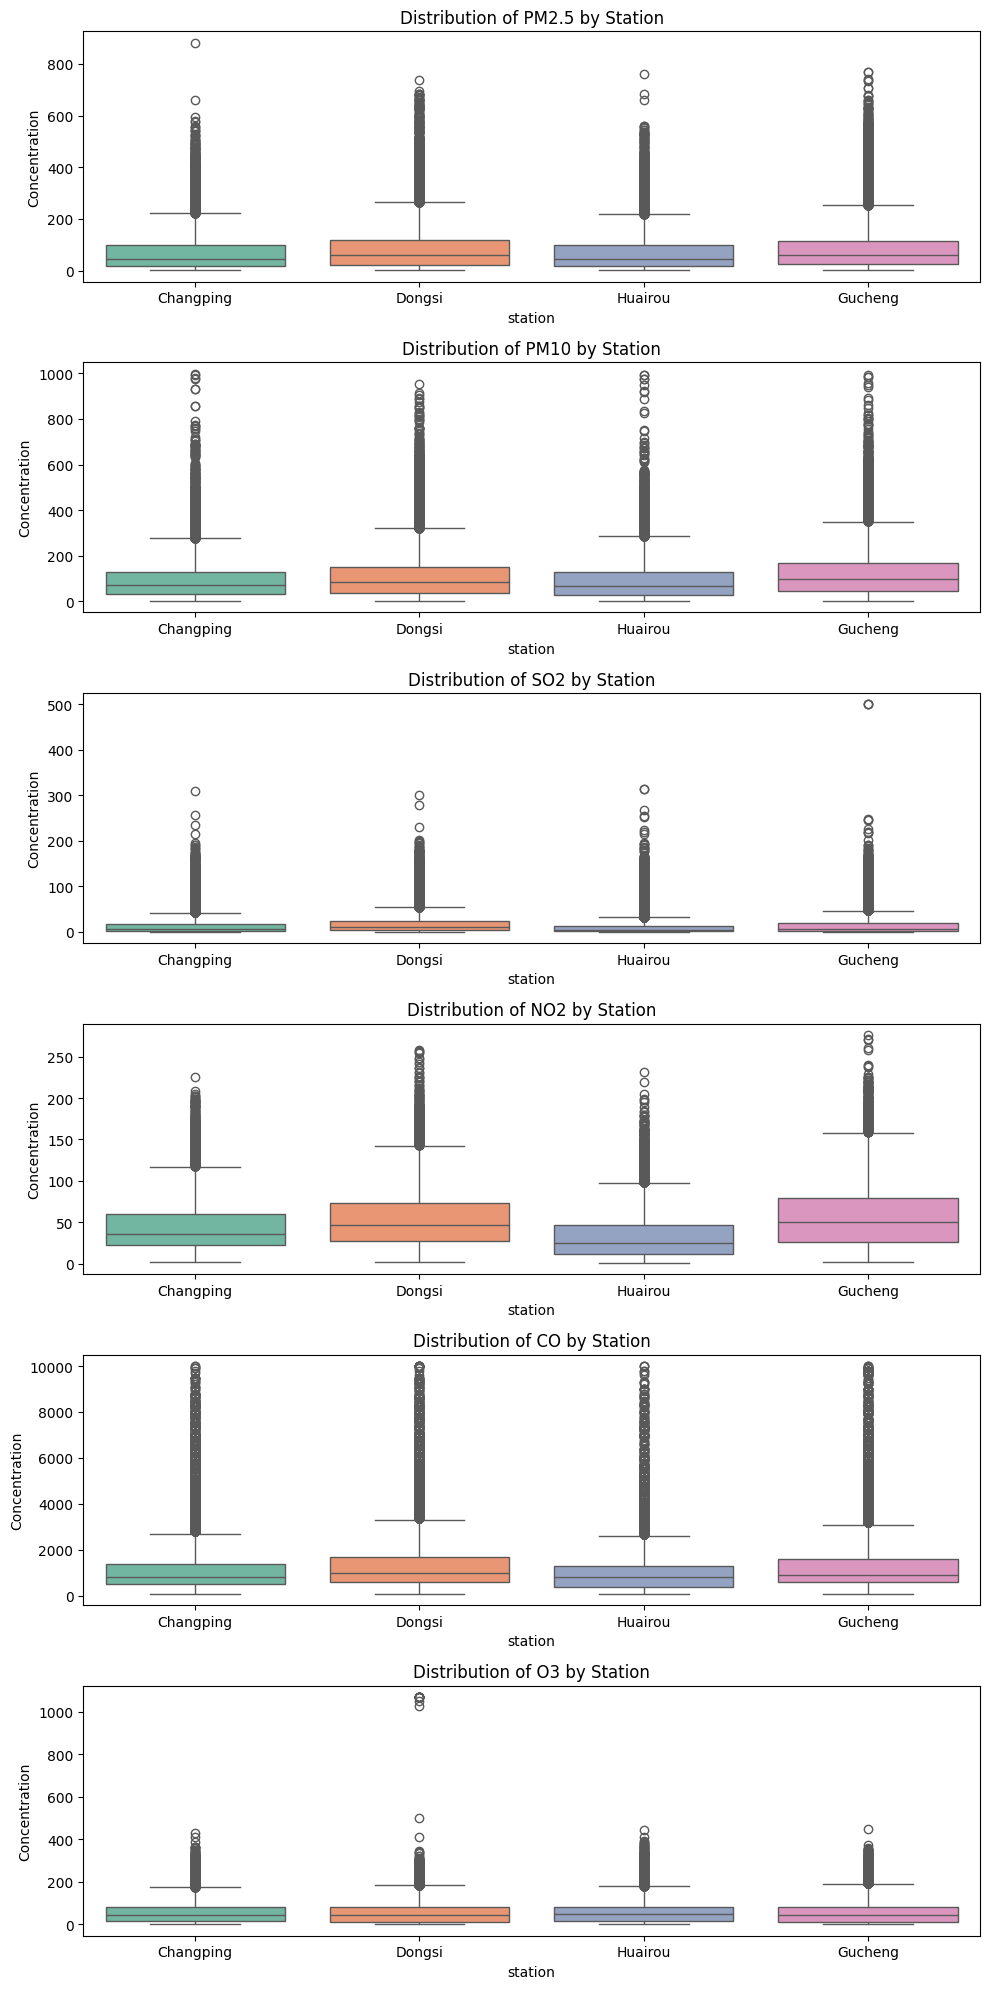

--- Outlier Detection Bounds (IQR Method) per Station ---


PM2.5   PM10   SO2       NO2      CO        O3
station                                                          
Changping Lower -105.000 -111.5 -22.0  -35.5373  -850.0  -80.9085
          Upper  223.000  276.5  42.0  117.8955  2750.0  176.5451
Dongsi    Lower -123.500 -131.5 -26.0  -42.0000 -1050.0  -91.5000
          Upper  264.500  320.5  54.0  142.0000  3350.0  184.5000
Gucheng   Lower -113.625 -138.0 -25.0  -53.5000  -900.0  -99.5000
          Upper  253.375  350.0  47.0  158.5000  3100.0  192.5000
Huairou   Lower -104.500 -126.5 -16.0  -39.0000  -950.0  -79.5000
          Upper  219.500  285.5  32.0   97.0000  2650.0  180.5000

In [ ]:
# 1. Visualize distributions by station using boxplots
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 20))

for i, col in enumerate(pollutants):
    sns.boxplot(x='station', y=col, data=df, ax=axes[i], palette='Set2',hue='station',legend=False)
    axes[i].set_title(f'Distribution of {col} by Station')
    axes[i].set_ylabel('Concentration')

plt.tight_layout()
plt.show()

# 2. Compute IQR bounds per station for a quantitative summary
def get_iqr_bounds(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    return pd.Series({'Lower': Q1 - 1.5 * IQR, 'Upper': Q3 + 1.5 * IQR})

outlier_bounds = df.groupby('station')[pollutants].apply(lambda x: x.apply(get_iqr_bounds))
print("--- Outlier Detection Bounds (IQR Method) per Station ---")
display(outlier_bounds)

### **Inference from Station-wise Outlier Detection**

The station-wise box plots and IQR bounds show that all pollutant variables contain substantial upper-end outliers across the four stations. In every case, the distributions are **positively skewed**, with a large number of observations extending far above the upper whisker, which indicates that extreme pollution episodes are common in the dataset rather than isolated rare errors.

For **PM2.5** and **PM10**, all stations display many high-value outliers, but the urban stations, especially **Dongsi** and **Gucheng**, show wider spreads and higher upper bounds than the suburban stations. The IQR upper bounds for **PM2.5** are **264.5** in Dongsi and **253.4** in Gucheng, compared with **223.0** in Changping and **219.5** in Huairou. A similar pattern is observed for **PM10**, where **Gucheng (350.0)** and **Dongsi (320.5)** have higher upper bounds than **Huairou (285.5)** and **Changping (276.5)**. This suggests that urban stations experience stronger and more frequent extreme particulate pollution events.

For the gaseous pollutants, **NO2** and **CO** also show clear urban dominance in outlier behaviour. The upper IQR bound for **NO2** reaches **158.5** in Gucheng and **142.0** in Dongsi, whereas it is lower in Changping (**117.9**) and Huairou (**97.0**). For **CO**, the upper bounds are highest in **Dongsi (3350.0)** and **Gucheng (3100.0)**, compared with **2750.0** in Changping and **2650.0** in Huairou. These results imply that traffic and combustion-related emissions are more extreme and variable in the urban stations.

The **O3** box plot shows a slightly different pattern. While all stations contain many upper-end outliers, **Gucheng** has the highest IQR upper bound (**192.5**), followed by **Dongsi (184.5)**, **Huairou (180.5)**, and **Changping (176.5)**. However, Dongsi also shows exceptionally extreme O3 spikes above **1000**, which stand out far beyond the normal whisker range. This indicates that although overall O3 spread is fairly similar across stations, some urban episodes are unusually intense and may need special attention.

For **SO2**, outliers are again present at all stations, with **Dongsi** showing the highest upper bound (**54.0**) and **Gucheng** next (**47.0**), while Changping and Huairou remain lower. This reinforces the same station-wise pattern seen in the other pollutants, where urban locations tend to have both higher typical levels and more extreme pollution peaks.

Overall, the outlier analysis confirms that extreme pollutant values are a real and important characteristic of the dataset, especially in the urban stations. Since these high values may represent genuine severe pollution episodes rather than simple recording errors, they should not be removed blindly. A more suitable preprocessing approach would be to handle them **station-wise**, using methods such as capping or winsorization, while preserving the underlying spatial pollution differences across stations.

## **Data preprocessing**

### **Feature Engineering**

In [9]:
# Create Datetime from components and drop redundant columns
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df['day_name'] = df['datetime'].dt.day_name() # 'Monday' etc.
df['week'] = df['datetime'].dt.isocalendar().week.astype(int)

A proper `datetime` column was created by combining the separate `year`, `month`, `day`, and `hour` columns into a single timestamp variable. This was done because time-series analysis is more effective when temporal information is stored in a unified datetime format, allowing easier extraction of seasonal and hourly patterns.

In [10]:
def get_season(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    elif month in [9, 10, 11]: return 'Autumn'
    else: return 'Winter'

df['season'] = df['month'].apply(get_season)
df['heating_season'] = df['month'].isin([11, 12, 1, 2, 3]).astype(int)
df['time_of_day'] = pd.cut(df['hour'],
                           bins=[-1, 4, 11, 16, 20, 23],
                           labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Night'],
                           ordered=False)

The `season` variable was derived to capture broad seasonal patterns, since pollutant levels can vary significantly across spring, summer, autumn, and winter. A `heating_season` indicator was also created because air pollution in Beijing is strongly influenced by domestic and industrial heating during colder months. In addition, a `time_of_day` feature was generated to capture daily variations in pollutant concentration, as traffic flow, atmospheric stability, and human activity often differ between morning, afternoon, evening, and night

In [11]:
urban_stations = ['Dongsi', 'Gucheng']
suburban_stations = ['Changping', 'Huairou']

df['area_type'] = df['station'].apply(
    lambda x: 'Urban' if x in urban_stations else 'Suburban'
)

In [12]:
def china_aqi_from_pm25(pm25):
    if pd.isna(pm25):       return np.nan
    elif pm25 <= 35:        return 'Excellent'
    elif pm25 <= 75:        return 'Good'
    elif pm25 <= 115:       return 'Lightly Polluted'
    elif pm25 <= 150:       return 'Moderately Polluted'
    elif pm25 <= 250:       return 'Heavily Polluted'
    else:                   return 'Severely Polluted'

df['AQI_Category'] = df['PM2.5'].apply(china_aqi_from_pm25)

In [13]:
df['CO_mg'] = df['CO'] / 1000
# µg/m³ → mg/m³

# Use CO_mg in your pollutants list instead of CO
# CO will now show ~1.0–1.3 mg/m³ instead of 1000–1300 µg/m³

#### **Station-wise Winsorization**

In [14]:
# Saving a copy before cleaning
df_original = df.copy()

In [15]:
df_winsorized = df.copy()

In [16]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO_mg', 'O3']

def winsorize_stationwise(df, cols):
    df_clean = df.copy()
    for station in df_clean['station'].unique():
        mask = df_clean['station'] == station
        for col in cols:
            lower = df_clean.loc[mask, col].quantile(0.01)
            upper = df_clean.loc[mask, col].quantile(0.99)
            # Clip for pollutants: lower bound maxed at 0 to avoid negative physical values
            df_clean.loc[mask, col] = df_clean.loc[mask, col].clip(lower=max(lower, 0), upper=upper)
    return df_clean

df_winsorized = winsorize_stationwise(df, pollutants)

Outliers in the pollutant variables were handled using **station-wise winsorization** at the **1st and 99th percentiles**. This method was chosen because air pollution data often contains genuine extreme events, such as severe smog episodes, and removing them entirely could lead to the loss of important information. Winsorization preserves all observations while limiting the influence of extremely low and high values, making the data more stable for subsequent modelling. Applying this process station-wise was particularly important because the selected urban and suburban stations have different pollution distributions, and a global treatment could distort their spatial characteristics

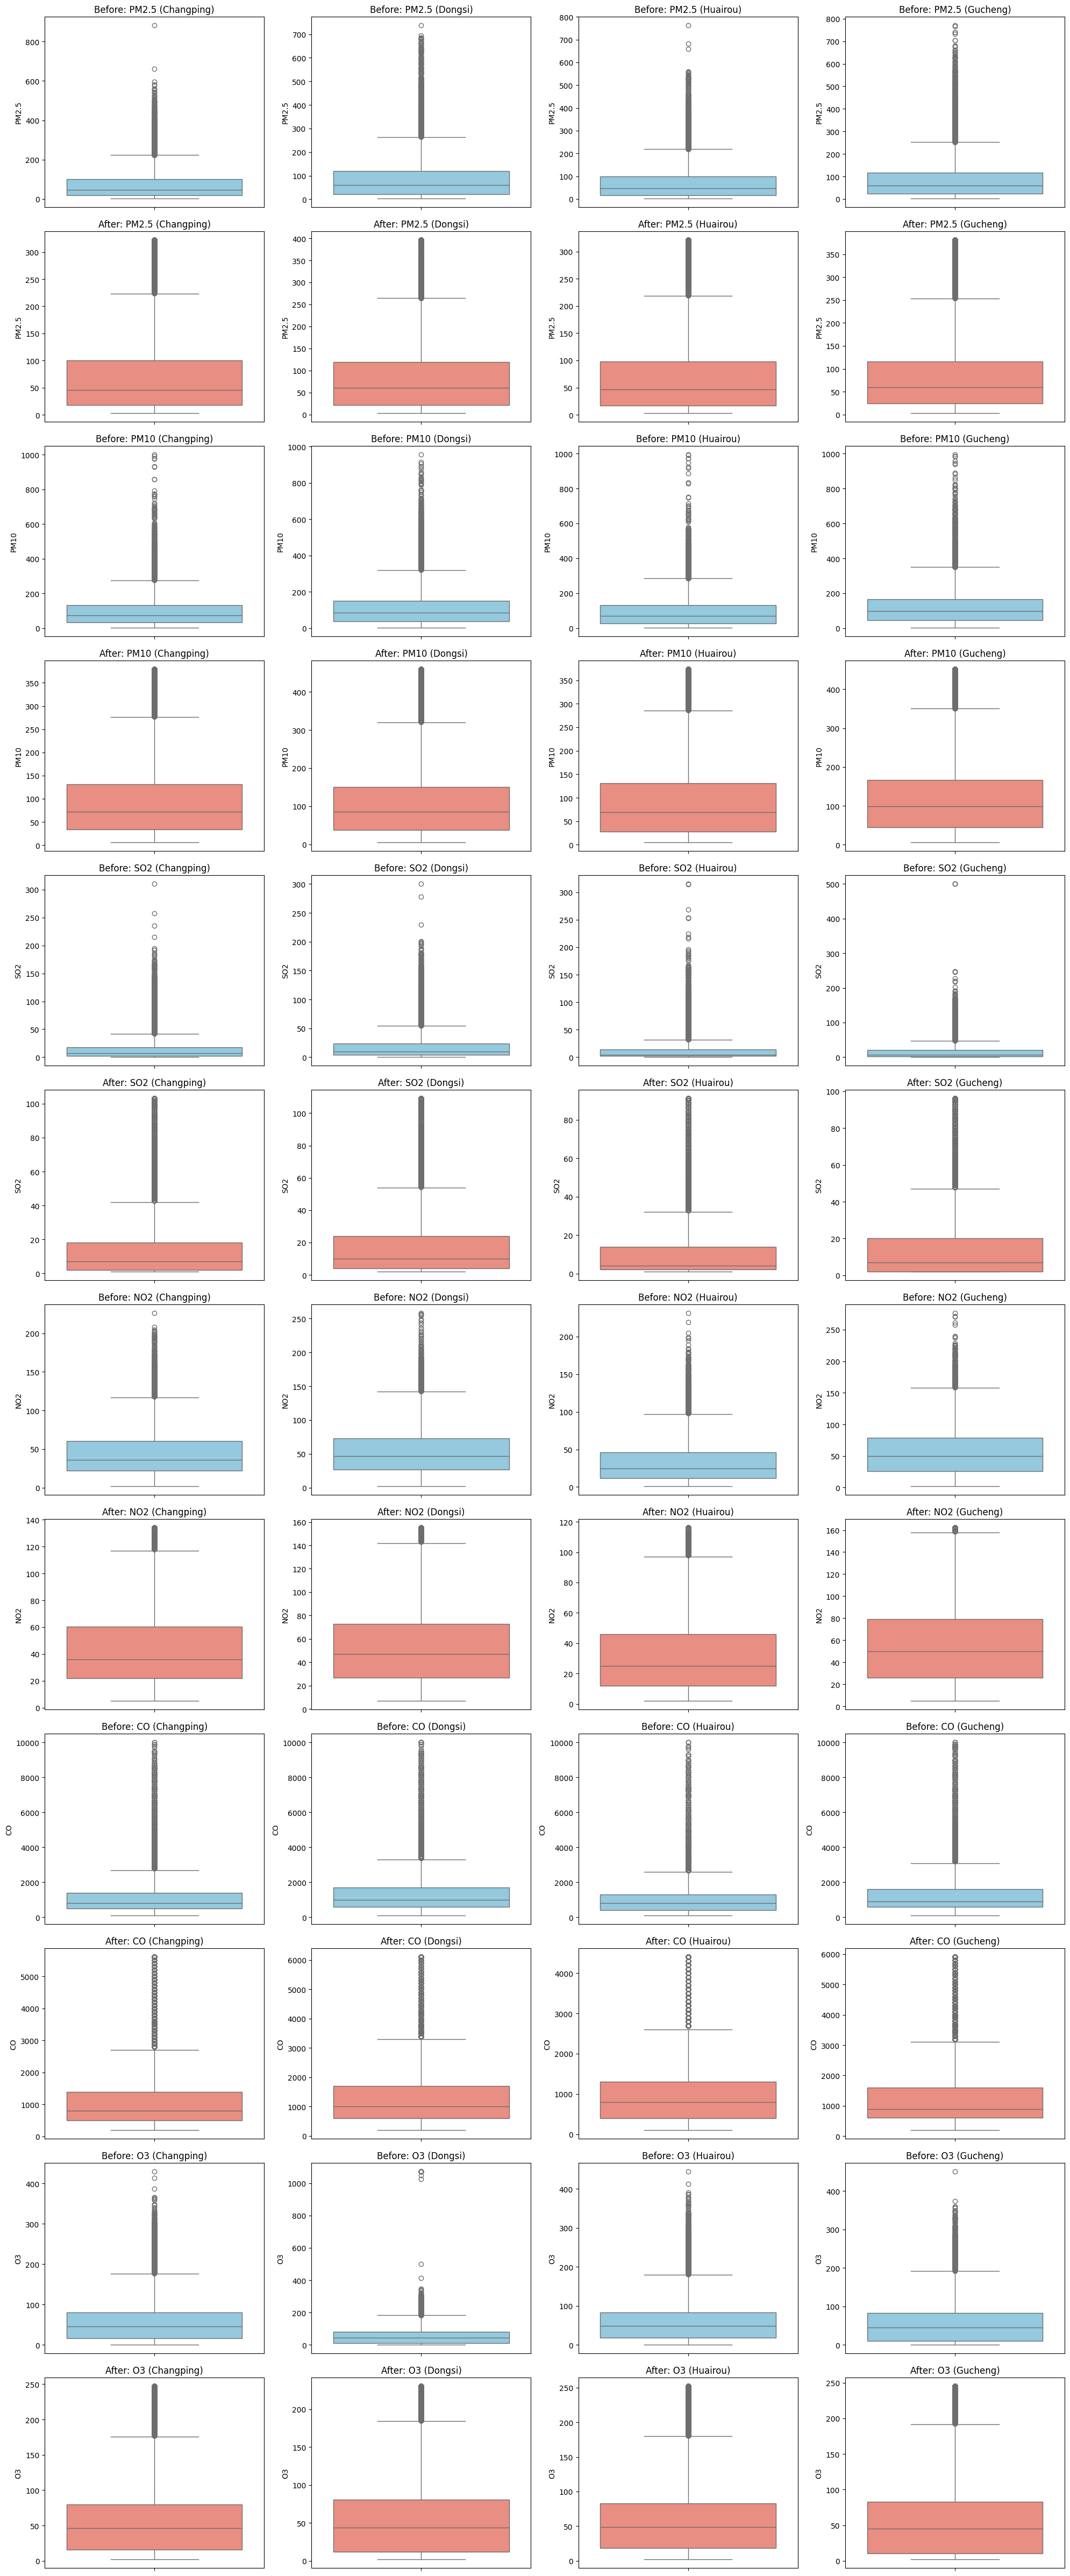

In [24]:
def compare_winsorization_by_pollutant(df_before, df_after, pollutant_cols, station_col='station'):
    stations = df_before[station_col].unique()
    n_pollutants = len(pollutant_cols)

    # 2 rows per pollutant → BEFORE + AFTER
    fig, axes = plt.subplots(n_pollutants * 2, len(stations), figsize=(5 * len(stations), 4 * n_pollutants * 2))

    for i, pollutant in enumerate(pollutant_cols):
        for j, station in enumerate(stations):

            # BEFORE (top row for this pollutant)
            sns.boxplot(
                y=df_before[df_before[station_col] == station][pollutant],
                ax=axes[i*2, j],
                color='skyblue'
            )
            axes[i*2, j].set_title(f'Before: {pollutant} ({station})')

            # AFTER (bottom row for this pollutant)
            sns.boxplot(
                y=df_after[df_after[station_col] == station][pollutant],
                ax=axes[i*2 + 1, j],
                color='salmon'
            )
            axes[i*2 + 1, j].set_title(f'After: {pollutant} ({station})')

    plt.tight_layout()
    plt.show()


# Example usage:
pollutant_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
compare_winsorization_by_pollutant(df_original, df_winsorized, pollutant_cols)


#### **Handling Missing Values**

In [17]:
# Station-wise Imputation (Median)
# Applying to pollutants and meteorological columns
all_cols = pollutants + ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in all_cols:
    df_winsorized[col] = df_winsorized.groupby('station')[col].transform(lambda x: x.fillna(x.median()))


In [18]:
df_winsorized['wd'] = df_winsorized.groupby('station')['wd'].ffill().bfill()

Missing values were handled using **station-wise median imputation** for the numeric pollutant and meteorological variables. The median was selected because it is more robust than the mean for skewed environmental data and is less affected by remaining high pollution values. Performing the imputation separately for each station ensures that the urban–suburban differences are preserved and that missing observations are filled using values representative of the same monitoring site rather than the full combined dataset.

## **Exploratory Data Analysis**

#### **Pollutant Analysis**

In [19]:
station_order  = ['Gucheng', 'Dongsi', 'Changping', 'Huairou']

station_colors = {
    'Gucheng':   '#E63946',   # red   — Urban
    'Dongsi':    '#F4A261',   # orange — Urban
    'Changping': '#2A9D8F',   # teal  — Suburban
    'Huairou':   '#457B9D'    # blue  — Suburban
}

station_area = {
    'Gucheng':   'Urban',
    'Dongsi':    'Urban',
    'Changping': 'Suburban',
    'Huairou':   'Suburban'
}

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO_mg', 'O3']

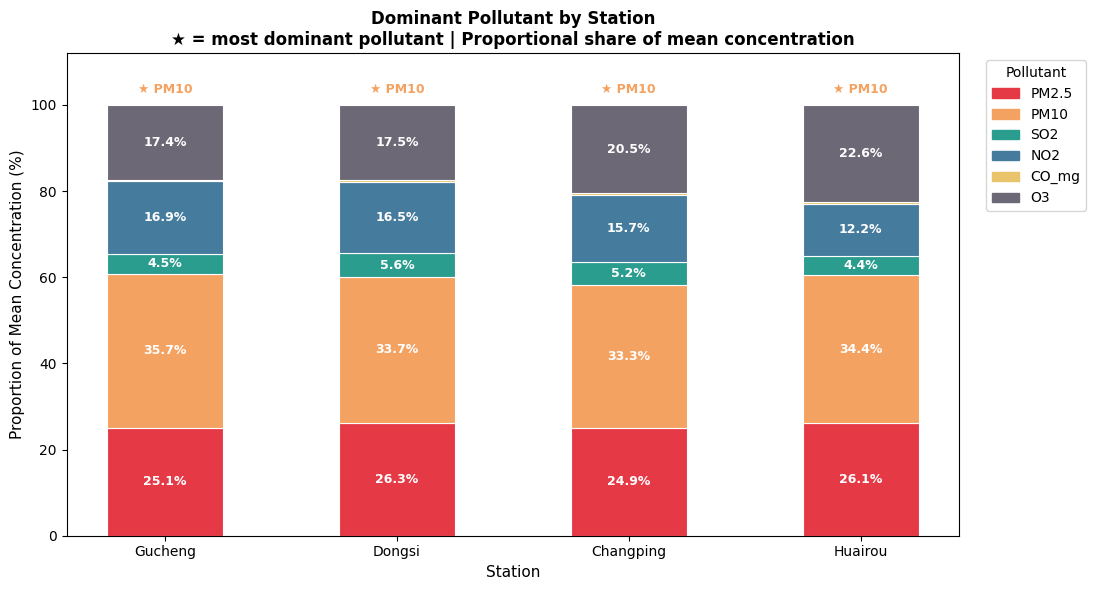

In [48]:
import matplotlib.patches as mpatches

pol_colors = {
    'PM2.5': '#E63946', 'PM10': '#F4A261', 'SO2': '#2A9D8F',
    'NO2':   '#457B9D', 'CO_mg':   '#E9C46A', 'O3':  '#6D6875'
}
station_order = ['Gucheng', 'Dongsi', 'Changping', 'Huairou']

# Mean per station per pollutant
station_means = df_winsorized.groupby('station')[pollutants].mean()
station_means = station_means.reindex(station_order)

# Normalise to 100%
station_pct = station_means.div(station_means.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(station_order))

for pol in pollutants:
    vals = station_pct[pol].values
    bars = ax.bar(station_order, vals, bottom=bottom,
                  color=pol_colors[pol], label=pol,
                  width=0.5, edgecolor='white', linewidth=0.8)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:   # only label if slice is wide enough to read
            ax.text(i, b + v / 2, f'{v:.1f}%',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals

# Annotate dominant pollutant per station
for i, station in enumerate(station_order):
    dominant = station_pct.loc[station].idxmax()
    dom_pct  = station_pct.loc[station].max()
    ax.text(i, 102, f'★ {dominant}',
            ha='center', va='bottom', fontsize=9,
            fontweight='bold', color=pol_colors[dominant])

ax.set_ylim(0, 112)
ax.set_ylabel('Proportion of Mean Concentration (%)', fontsize=11)
ax.set_xlabel('Station', fontsize=11)
ax.set_title('Dominant Pollutant by Station\n'
             '★ = most dominant pollutant | Proportional share of mean concentration',
             fontsize=12, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=pol_colors[p], label=p) for p in pollutants],
          loc='upper right', bbox_to_anchor=(1.15, 1), title='Pollutant')
ax.set_yticks(range(0, 101, 20))
plt.tight_layout()
plt.show()

The stacked bar chart reveals that **PM10 is the
single most dominant pollutant across all four monitoring stations**,
accounting for the largest proportional share of mean concentration:
Gucheng (35.7%), Dongsi (33.7%), Changping (33.3%), and Huairou (34.4%).
PM2.5 is consistently the second largest contributor, ranging from 24.9%
at Changping to 26.3% at Dongsi. Collectively, PM10 and PM2.5 account
for over 58–62% of the total pollutant load at every station, confirming
that **coarse and fine particulate matter are the primary drivers of air
quality degradation across Beijing**, irrespective of whether the station
is urban or suburban.

A notable urban–suburban contrast is observed for O3. Suburban stations
record a proportionally higher ozone share — Changping (20.5%) and
Huairou (22.6%) — compared to urban stations Gucheng (17.4%) and Dongsi
(17.5%). This inverse pattern, where ozone proportionally increases away
from the urban core, is consistent with the atmospheric NO-titration
mechanism: elevated nitrogen oxide (NO) emissions from dense urban
traffic chemically consume ground-level ozone, suppressing its
concentration in city centres relative to suburban peripheries.

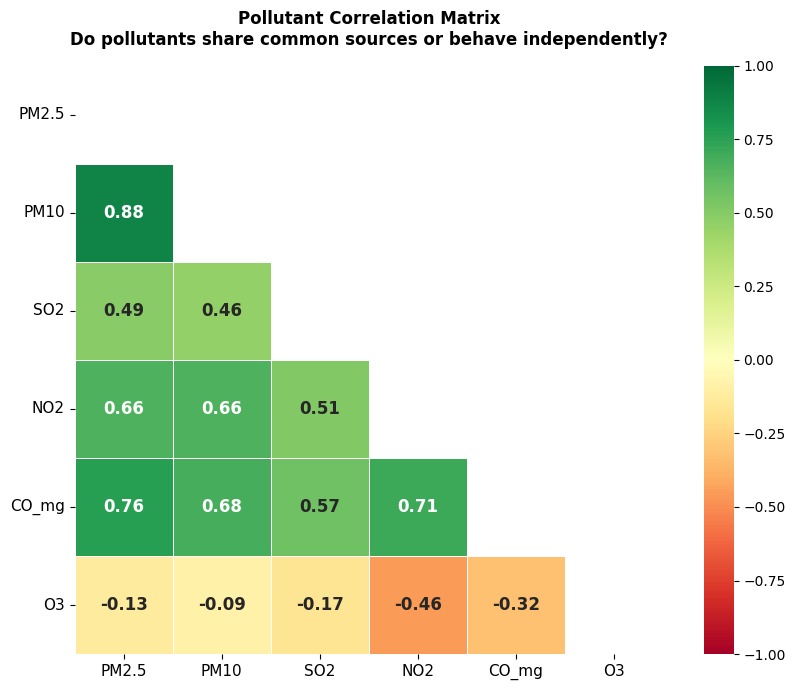

In [47]:

corr_matrix = df_winsorized[pollutants].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,                    # show lower triangle only — avoids redundancy
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Pollutant Correlation Matrix\n'
             'Do pollutants share common sources or behave independently?',
             fontsize=12, fontweight='bold', pad=15)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

The Pearson correlation matrix provides statistical evidence
for shared emission sources across the Beijing monitoring network.
The strongest correlation is between **PM2.5 and PM10 (r = 0.88)**,
indicating that both particle sizes originate from the same combustion
and road dust-raising processes. The strong positive associations of
**CO_mg with PM2.5 (r = 0.76)**, **CO_mg with NO2 (r = 0.71)**, and
**CO_mg with PM10 (r = 0.68)** further confirm that carbon monoxide,
particulate matter, and nitrogen dioxide are co-emitted predominantly
through incomplete fossil fuel combustion in vehicular traffic and
residential coal heating — both of which intensify during Beijing's
winter season.

**SO2 shows moderate positive correlations** with PM2.5 (r = 0.49) and
PM10 (r = 0.46), reflecting its partial origin in coal combustion, though
weaker than the traffic-dominated pollutants. This suggests that SO2
sources are more diffuse and less directly linked to the same traffic
emission events that produce PM and NO2.

In contrast, **O3 shows negative correlations with all combustion-related
pollutants**: most strongly with NO2 (r = −0.46) and CO_mg (r = −0.32),
and weakly with PM2.5 (r = −0.13) and PM10 (r = −0.09). The inverse
relationship between O3 and NO2 is particularly significant and reflects
established photochemical chemistry: while NO2 photolysis produces ozone
under sunlight, the simultaneous emission of NO from combustion sources
rapidly consumes O3 in polluted urban air.

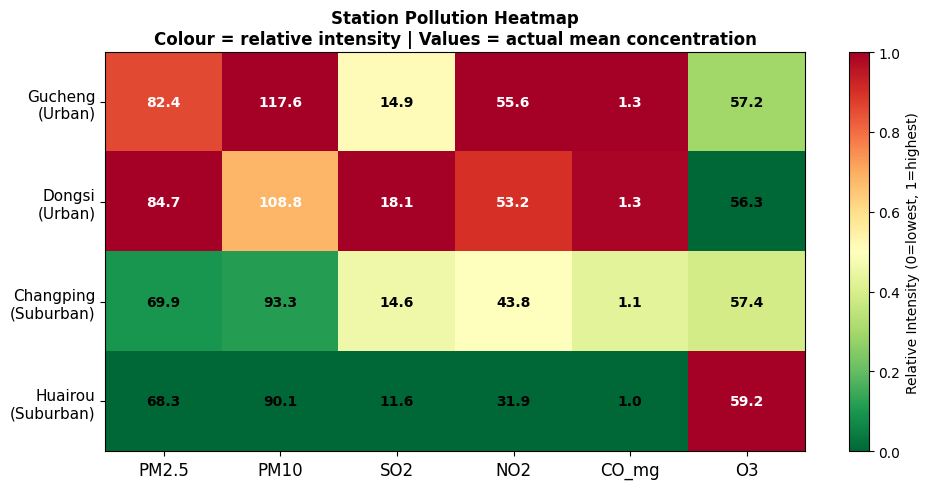

In [46]:
station_means = df_winsorized.groupby('station')[pollutants].mean()
station_means = station_means.reindex(['Gucheng','Dongsi','Changping','Huairou'])

# Normalise row-wise for colour (but show actual values)
station_norm = (station_means - station_means.min()) / \
               (station_means.max() - station_means.min())

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(station_norm.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(pollutants)))
ax.set_xticklabels(pollutants, fontsize=12)
ax.set_yticks(range(4))
ax.set_yticklabels(['Gucheng\n(Urban)','Dongsi\n(Urban)',
                    'Changping\n(Suburban)','Huairou\n(Suburban)'], fontsize=11)

# Annotate actual values
for i in range(4):
    for j in range(len(pollutants)):
        val = station_means.iloc[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if station_norm.iloc[i,j] > 0.6 else 'black')

plt.colorbar(im, ax=ax, label='Relative Intensity (0=lowest, 1=highest)')
ax.set_title('Station Pollution Heatmap\n'
             'Colour = relative intensity | Values = actual mean concentration',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The station pollution heatmap provides the most
comprehensive view of relative and absolute pollution intensity across
all four stations and six pollutants. The clear red-to-green colour
gradient from top to bottom confirms a **systematic urban-to-suburban
pollution gradient**: urban stations (Gucheng, Dongsi) consistently
record higher concentrations than suburban stations (Changping, Huairou)
for five of the six pollutants measured.

**Gucheng is the most polluted station overall**, recording the highest
mean concentration for PM10 (117.6 µg/m³), NO2 (55.6 µg/m³). Dongsi records the
highest PM2.5 mean (84.7 µg/m³), marginally exceeding Gucheng (82.4
µg/m³), and the
highest relative intensity for SO2 (18.1 µg/m³) and is the most polluted station specifically for this
health-critical pollutant. Both urban stations exceed the China Grade II
annual PM2.5 standard of 35 µg/m³ (GB 3095-2012) by more than double.

**Huairou is the cleanest station**, recording the lowest mean values for
PM2.5 (68.3 µg/m³), PM10 (90.1 µg/m³), SO2 (11.6 µg/m³), NO2 (31.9
µg/m³), and CO_mg (1.0 mg/m³). The sole exception is O3, where Huairou
records the highest mean concentration (59.2 µg/m³) — even exceeding
the urban stations — directly consistent with the NO-titration dynamics. The **SO2 column shows minimal mean variation** across all four stations (range: 11.6–18.1 µg/m³), suggesting
that sulphur dioxide does not exhibit a strong urban–suburban gradient and
likely originates from spatially distributed regional coal combustion
rather than localised urban traffic.

### **Temporal Analysis**

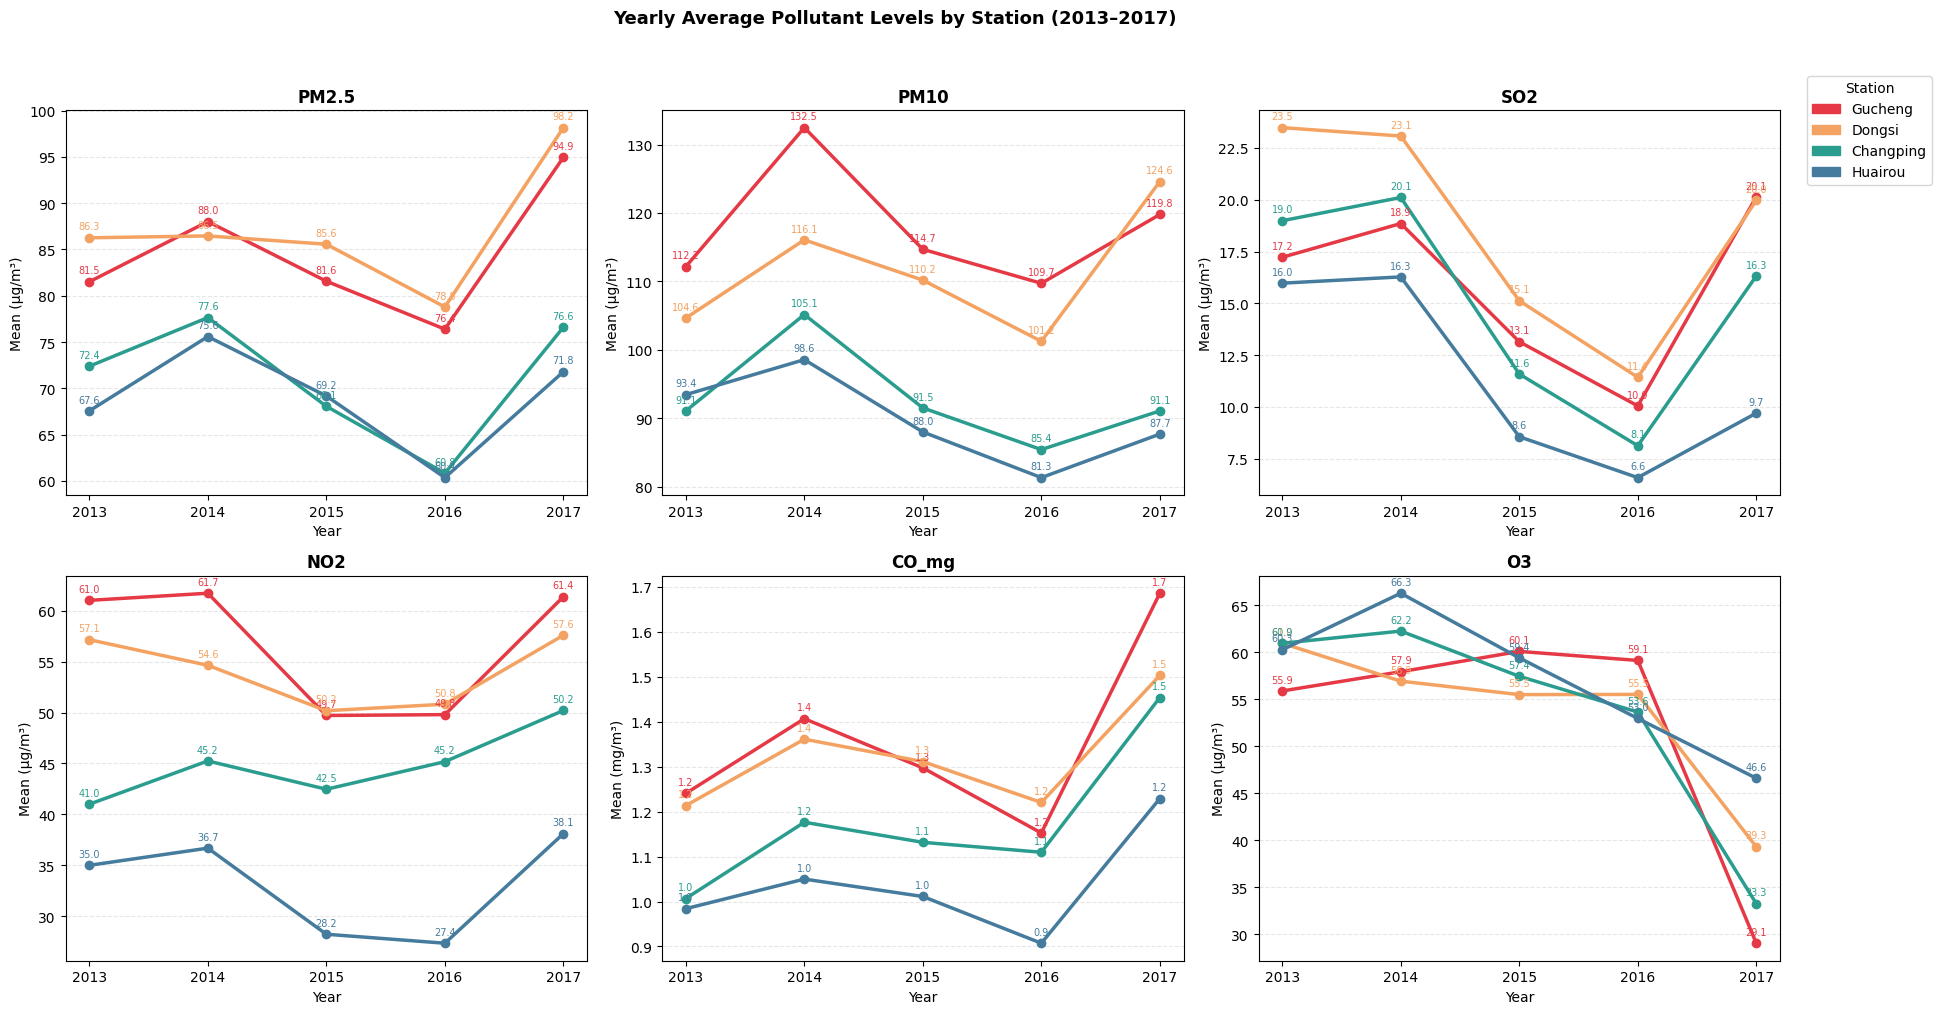

In [63]:
years = sorted(df_winsorized['year'].unique())
yearly = df_winsorized.groupby(['year', 'station'])[pollutants].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, pol in enumerate(pollutants):
    ax = axes[idx]
    for station in station_order:
        sub = yearly[yearly['station'] == station].sort_values('year')
        ax.plot(sub['year'], sub[pol],
                marker='o', markersize=6, linewidth=2.5,
                color=station_colors[station], label=station)
        # Add value annotations on each point
        for _, row in sub.iterrows():
            ax.annotate(f"{row[pol]:.1f}",
                        xy=(row['year'], row[pol]),
                        xytext=(0, 6), textcoords='offset points',
                        ha='center', fontsize=7,
                        color=station_colors[station])

    ax.set_title(pol, fontsize=12, fontweight='bold')
    ax.set_xticks(years)
    ax.set_xlabel('Year')
    unit = 'mg/m³' if pol == 'CO_mg' else 'µg/m³'
    ax.set_ylabel(f'Mean ({unit})')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Yearly Average Pollutant Levels by Station (2013–2017)\n'
             ,
             fontsize=13, fontweight='bold', y=1.01)
fig.legend(handles=[mpatches.Patch(color=station_colors[s], label=s)
                    for s in station_order],
           loc='upper right', bbox_to_anchor=(1.08, 0.95), title='Station')
plt.tight_layout()
plt.show()

The yearly line chart reveals a non-linear pollution
trajectory across all four stations. Rather than a consistent decline,
most pollutants — particularly PM2.5, PM10, SO2 and CO_mg — follow a
**dip-then-rise pattern**: concentrations fall from 2013 to a trough
in 2015–2016, then sharply rebound in 2017. For example, Dongsi PM2.5
drops from 86.5 µg/m³ in 2013 to 79 µg/m³ in 2016, before rising
steeply to 94.9 µg/m³ in 2017. This suggests that Beijing's emission
control policies (implemented under the 2013 Air Pollution Action Plan)
produced measurable short-term improvements, but their effect was not
sustained into 2017, possibly due to increased industrial activity
or anomalous meteorological conditions in that year
(Li et al., 2024).

**O3 follows a declining trend from 2013 to 2017**, All four stations show O3 falling from ~56–66 µg/m³ in 2013–2016
down to ~29–46 µg/m³ in 2017 — with a particularly sharp drop in
2017 for Gucheng (31.1 µg/m³), Changping (33.4 µg/m³), and Dongsi
(39.5 µg/m³). This unusual multi-year O3 decline may reflect
increased NOx scavenging of ozone in years with higher traffic
emissions, or inter-annual variability in cloud cover and solar
radiation intensity reducing photochemical O3 production

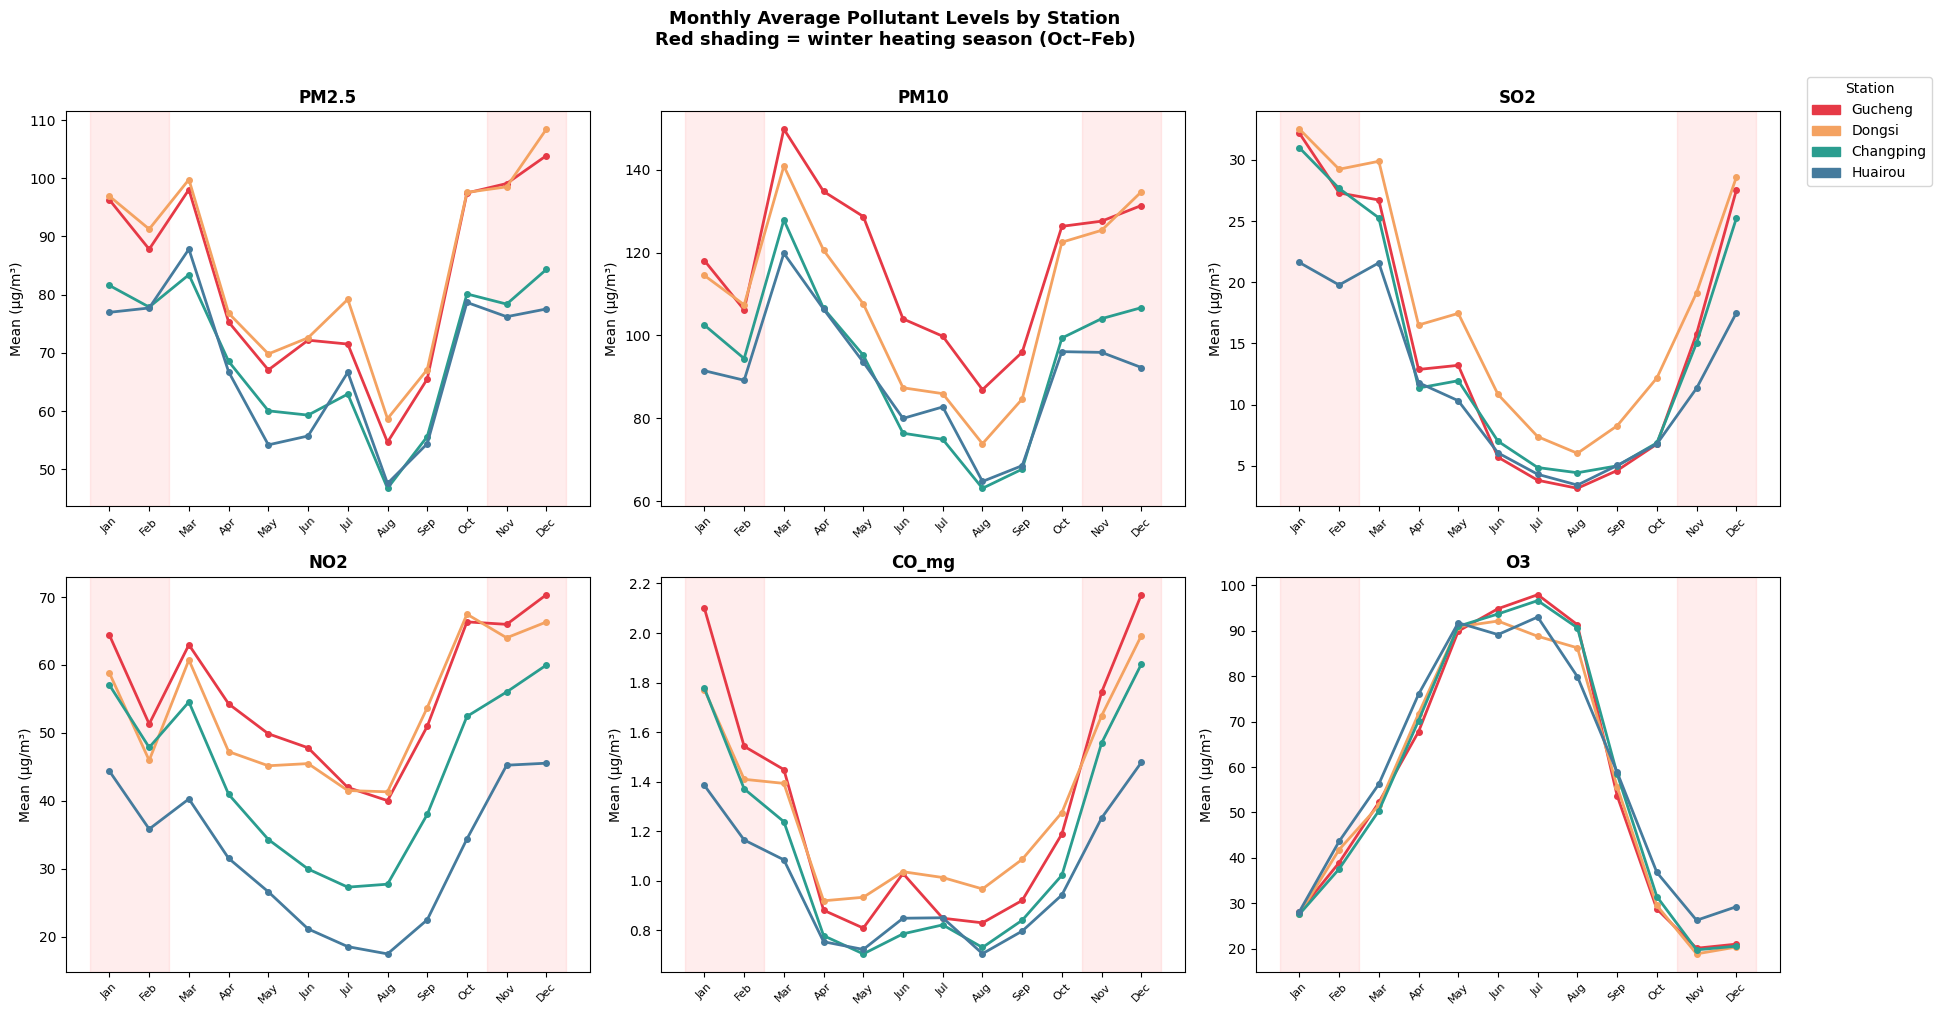

In [62]:
monthly = df_winsorized.groupby(['month','station'])[pollutants].mean().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, pol in enumerate(pollutants):
    ax = axes[idx]
    for station in station_order:
        sub = monthly[monthly['station'] == station].sort_values('month')
        ax.plot(sub['month'], sub[pol],
                marker='o', markersize=4, linewidth=2,
                color=station_colors[station],
                label=station if idx == 0 else '')

    # Winter shading on every panel
    ax.axvspan(10.5, 12.5, alpha=0.07, color='red')
    ax.axvspan(0.5, 2.5, alpha=0.07, color='red')
    ax.set_title(f'{pol}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
    ax.set_ylabel('Mean (µg/m³)' if pol != 'CO' else 'Mean (mg/m³)')

fig.suptitle('Monthly Average Pollutant Levels by Station\n'
             'Red shading = winter heating season (Oct–Feb)',
             fontsize=13, fontweight='bold', y=1.01)
fig.legend(handles=[mpatches.Patch(color=station_colors[s], label=s)
                    for s in station_order],
           loc='upper right', bbox_to_anchor=(1.08, 0.95),
           title='Station', fontsize=10)
plt.tight_layout()
plt.show()

The monthly line chart reveals a pronounced **U-shaped
seasonal cycle** for combustion-related pollutants — PM2.5, PM10, NO2, SO2,
and CO_mg — with peaks in January–February and November–December
(highlighted by red shading), and a clear summer minimum in
July–August. Gucheng records its highest monthly PM2.5 mean in
November (105 µg/m³) and its lowest in August (45 µg/m³).
This pattern is consistent with Beijing's district heating season,
during which residential and commercial coal combustion intensifies
significantly, combined with winter atmospheric inversions that trap
pollutants near ground level (Zhang et al., 2015).

**O3 displays a strikingly inverted seasonal pattern** — a clear
bell-shaped curve peaking in June–July (90–99 µg/m³ across all
stations) and falling to its lowest in December–January (20–30
µg/m³). This inversion is driven by solar-induced photochemical
reactions: ozone production requires ultraviolet radiation, which
peaks in summer (Jacob, 1999). Notably, all four stations show
nearly identical O3 seasonal curves — confirming that ozone is
a regionally transported pollutant with no strong urban–suburban
gradient in its seasonal behaviour, unlike the combustion pollutants.

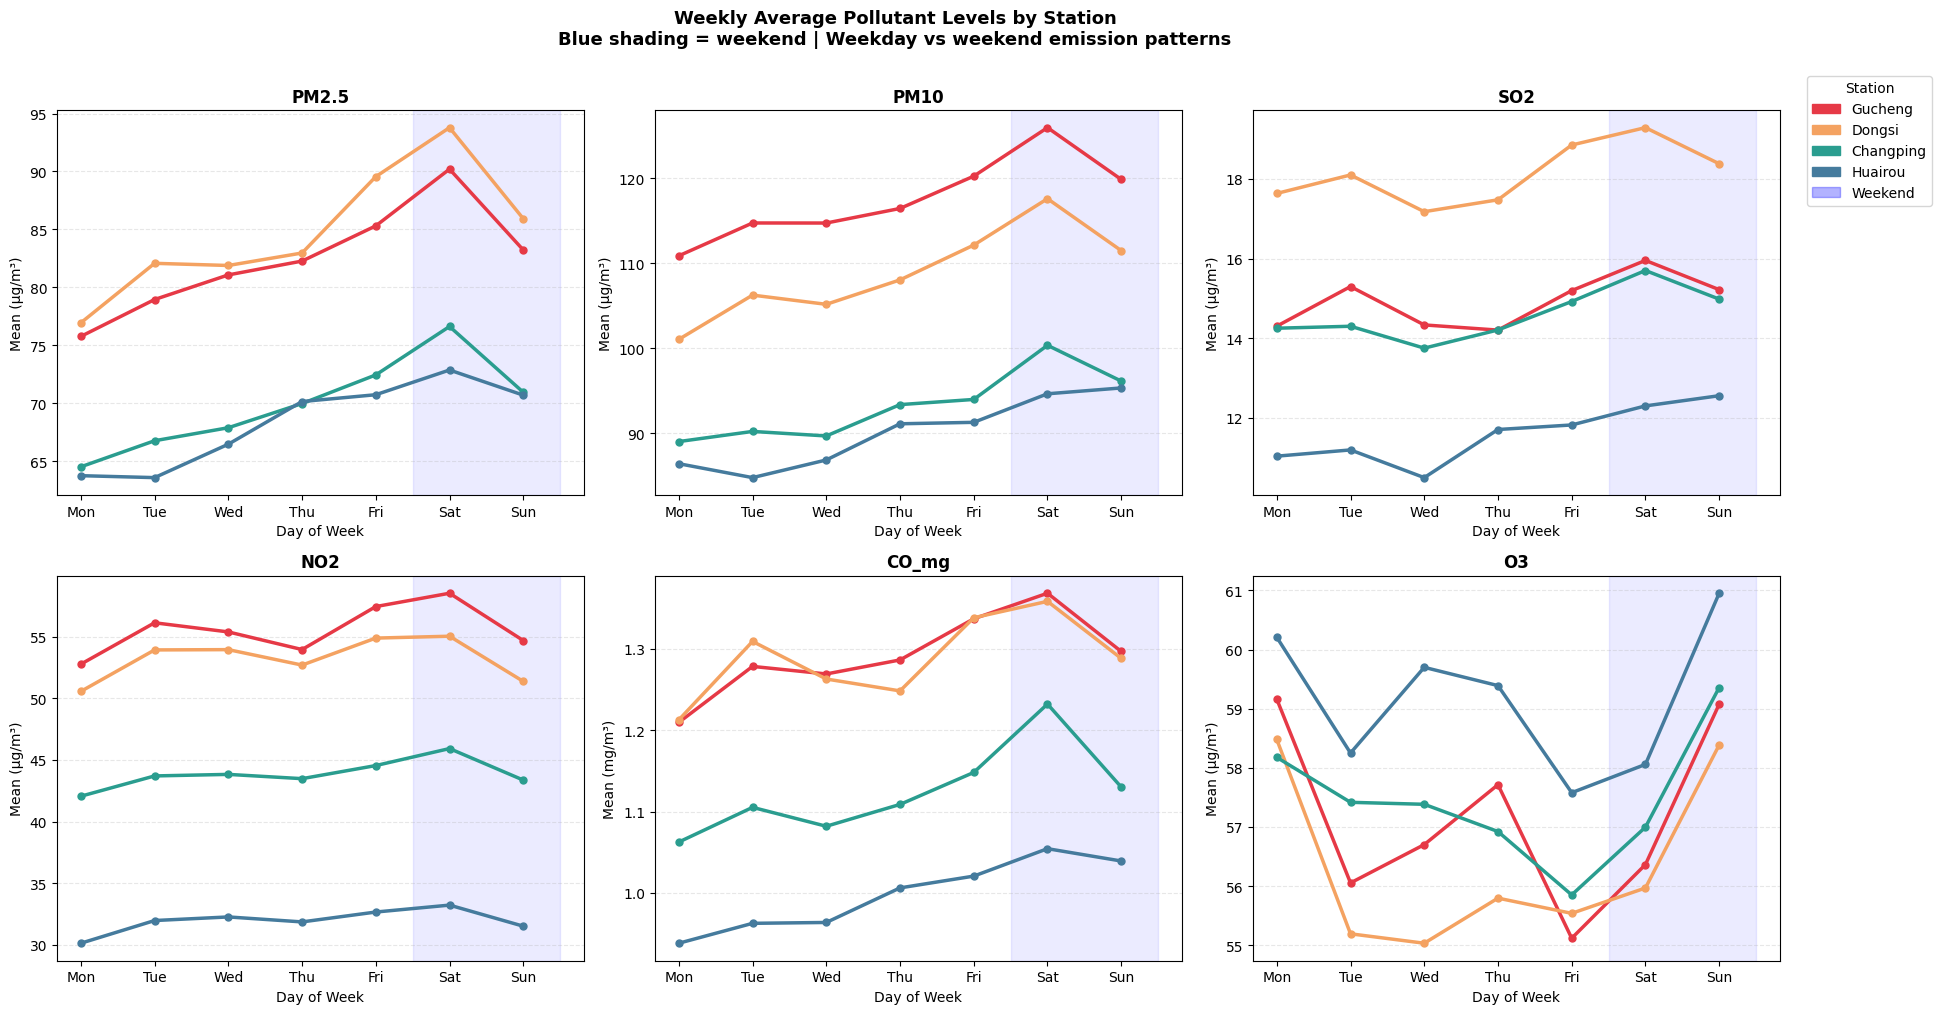

In [75]:
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

weekly = df_winsorized.groupby(['day_of_week', 'station'])[pollutants].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, pol in enumerate(pollutants):
    ax = axes[idx]
    for station in station_order:
        sub = weekly[weekly['station'] == station].sort_values('day_of_week')
        ax.plot(sub['day_of_week'], sub[pol],
                marker='o', markersize=5, linewidth=2.5,
                color=station_colors[station])

    ax.axvspan(4.5, 6.5, alpha=0.08, color='blue')
    ax.set_title(pol, fontsize=12, fontweight='bold')
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_labels)
    ax.set_xlabel('Day of Week')
    unit = 'mg/m³' if pol == 'CO_mg' else 'µg/m³'
    ax.set_ylabel(f'Mean ({unit})')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Weekly Average Pollutant Levels by Station\n'
             'Blue shading = weekend | Weekday vs weekend emission patterns',
             fontsize=13, fontweight='bold', y=1.01)
fig.legend(handles=[mpatches.Patch(color=station_colors[s], label=s)
                    for s in station_order] +
                   [mpatches.Patch(color='blue', alpha=0.3, label='Weekend')],
           loc='upper right', bbox_to_anchor=(1.08, 0.95), title='Station')
plt.tight_layout()
plt.show()

The weekly chart reveals a **systematic linear increase in pollution
from Monday through Saturday, followed by a gradual dip on Sunday**
across all combustion-related pollutants — PM2.5, PM10, NO2, CO_mg,
and SO2. For example, Gucheng PM2.5 rises steadily from ~76 µg/m³
on Monday to a weekly peak of ~90 µg/m³ on Saturday, before
declining slightly to ~83 µg/m³ on Sunday. Dongsi PM10 follows
the same trajectory, climbing from ~103 µg/m³ on Monday to ~122
µg/m³ on Saturday then easing back on Sunday. This pattern
suggests a **cumulative build-up of pollutants across the working
week** — driven by the progressive accumulation of traffic
emissions, industrial output, and residential heating activity
from Monday to Saturday — with Sunday providing a partial
recovery as activity levels begin to ease (Zhang et al., 2015).

**NO2 and CO_mg mirror this Monday-to-Saturday escalation**,
confirming that combustion-sourced emissions accumulate
progressively throughout the week rather than spiking on any
single day. **SO2 shows the same gradual weekly rise**, particularly
pronounced at Dongsi and Huairou, consistent with continuous
industrial and coal-heating activity that intensifies as the
week progresses. **O3 does not follow this linear pattern** —
it fluctuates irregularly across the week, with a sudden increase on Sunday at urban stations consistent with reduced
NO titration as Monday-to-Saturday traffic emissions begin
to ease, allowing ozone to briefly accumulate (Jacob, 1999).

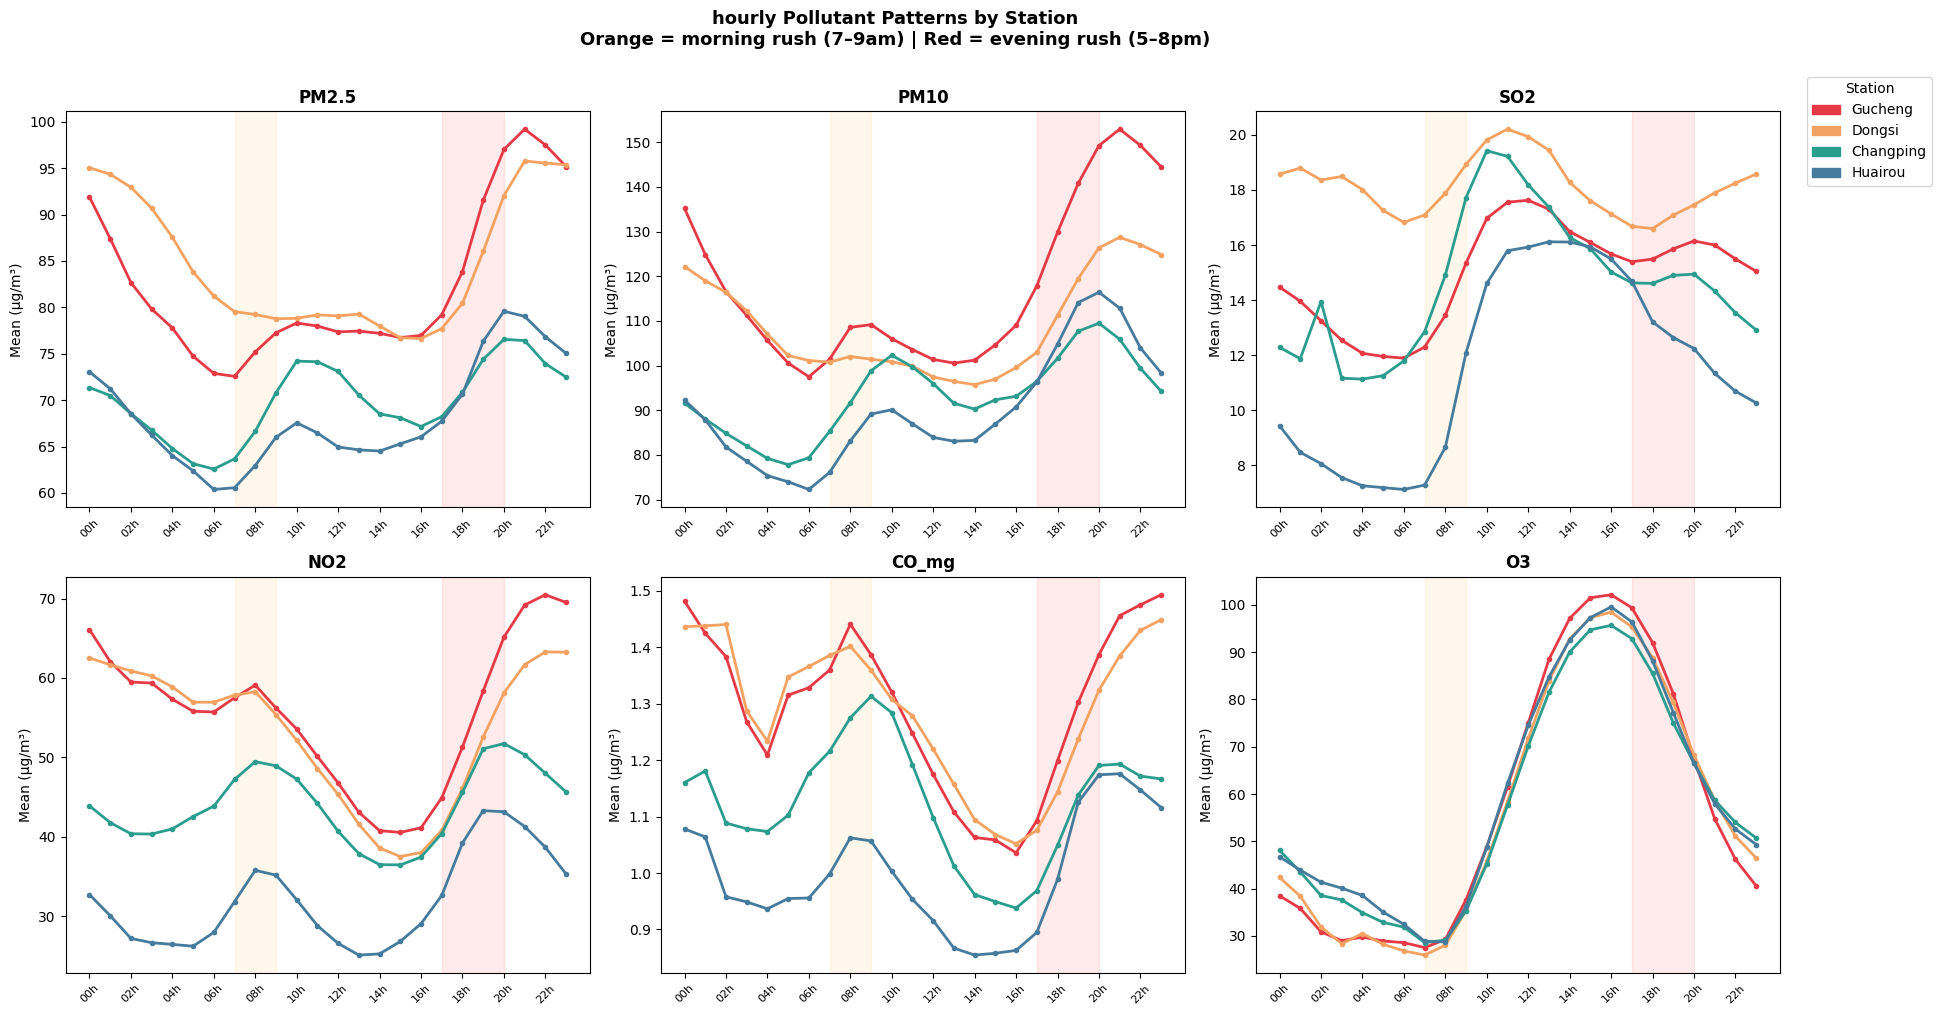

In [61]:
hourly = df_winsorized.groupby(['hour','station'])[pollutants].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, pol in enumerate(pollutants):
    ax = axes[idx]
    for station in station_order:
        sub = hourly[hourly['station'] == station].sort_values('hour')
        ax.plot(sub['hour'], sub[pol],
                marker='o', markersize=3, linewidth=2,
                color=station_colors[station],
                label=station if idx == 0 else '')

    # Rush hour shading
    ax.axvspan(7, 9, alpha=0.08, color='orange')
    ax.axvspan(17, 20, alpha=0.08, color='red')
    ax.set_title(f'{pol}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}h' for h in range(0, 24, 2)],
                       rotation=45, fontsize=8)
    ax.set_ylabel('Mean (µg/m³)' if pol != 'CO' else 'Mean (mg/m³)')

fig.suptitle('hourly Pollutant Patterns by Station\n'
             'Orange = morning rush (7–9am) | Red = evening rush (5–8pm)',
             fontsize=13, fontweight='bold', y=1.01)
fig.legend(handles=[mpatches.Patch(color=station_colors[s], label=s)
                    for s in station_order],
           loc='upper right', bbox_to_anchor=(1.08, 0.95),
           title='Station', fontsize=10)
plt.tight_layout()
plt.show()

The diurnal chart exposes the within-day pollution
rhythm driven by human activity cycles. PM2.5, PM10, NO2, and CO_mg
all exhibit a **dual-peak structure**: an evening peak between 18:00–
21:00 (coinciding with the evening rush hour and post-work cooking
and heating activity) and elevated concentrations at 00:00–02:00
driven by nocturnal boundary layer compression, which traps pollutants
close to the surface during cooler overnight hours. Concentrations
reach their daily minimum around 14:00–16:00, when solar heating
raises the atmospheric mixing height, dispersing surface-level
pollutants (Seinfeld & Pandis, 2016).

**O3 shows a completely opposite diurnal pattern** — its daily
minimum occurs in the early morning (06:00–08:00) and its maximum
at approximately 14:00–16:00. This midday peak directly corresponds
to peak solar intensity, confirming photochemical production as
the dominant O3 source. The morning NO2 panel shows a
corresponding morning peak at 07:00–09:00 (morning rush hour),
while O3 is simultaneously at its lowest — providing direct
hourly-scale evidence of the NO-titration mechanism identified
statistically. **SO2 shows a notable mid-morning
rise (08:00–10:00)** consistent with industrial activity and
power plant operation ramping up after overnight lows.

### **Meteorological Analysis**

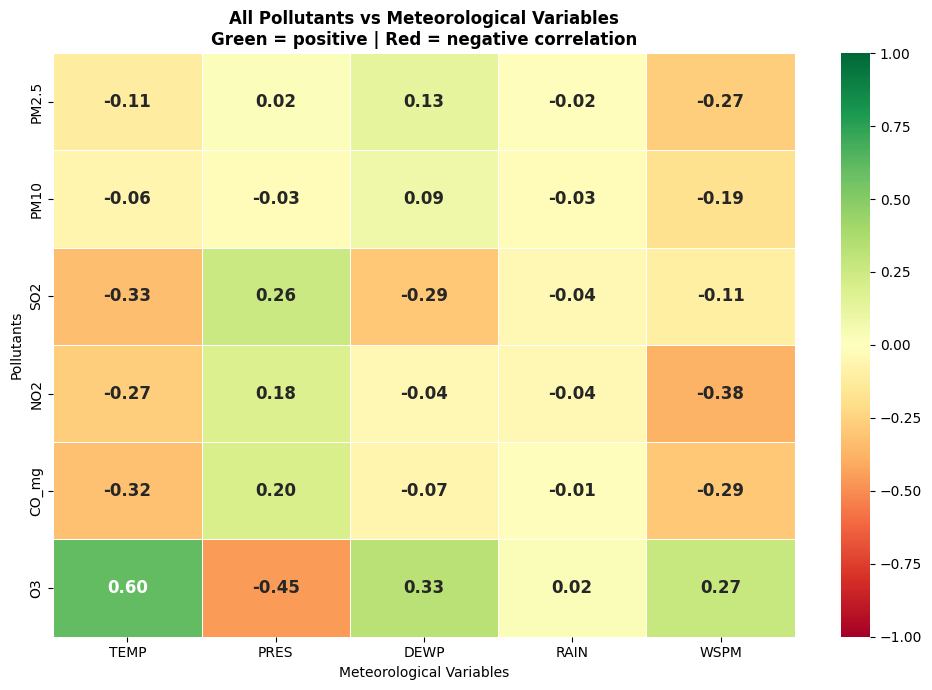

In [33]:
import seaborn as sns

met_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
pol_vars = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO_mg', 'O3']

cross_corr = df_winsorized[pol_vars + met_vars].corr().loc[pol_vars, met_vars]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cross_corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('All Pollutants vs Meteorological Variables\n'
             'Green = positive | Red = negative correlation',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Meteorological Variables')
ax.set_ylabel('Pollutants')
plt.tight_layout()
plt.show()

The cross-correlation heatmap reveals that meteorological variables
exert markedly different influences depending on the pollutant type.
Temperature (TEMP) emerges as the single most influential factor,
showing a strong positive correlation with O3 (r = 0.60) and
consistent negative correlations with combustion-related pollutants
SO2 (r = −0.33), CO (r = −0.32), and NO2 (r = −0.27). Wind speed
(WSPM) shows the strongest negative correlation with NO2 (r = −0.38),
confirming its role as a mechanical dispersal agent. Notably, rainfall
(RAIN) shows near-zero correlations across all pollutants in the
Pearson framework, suggesting its effect is episodic rather than
linearly persistent — a finding explored further

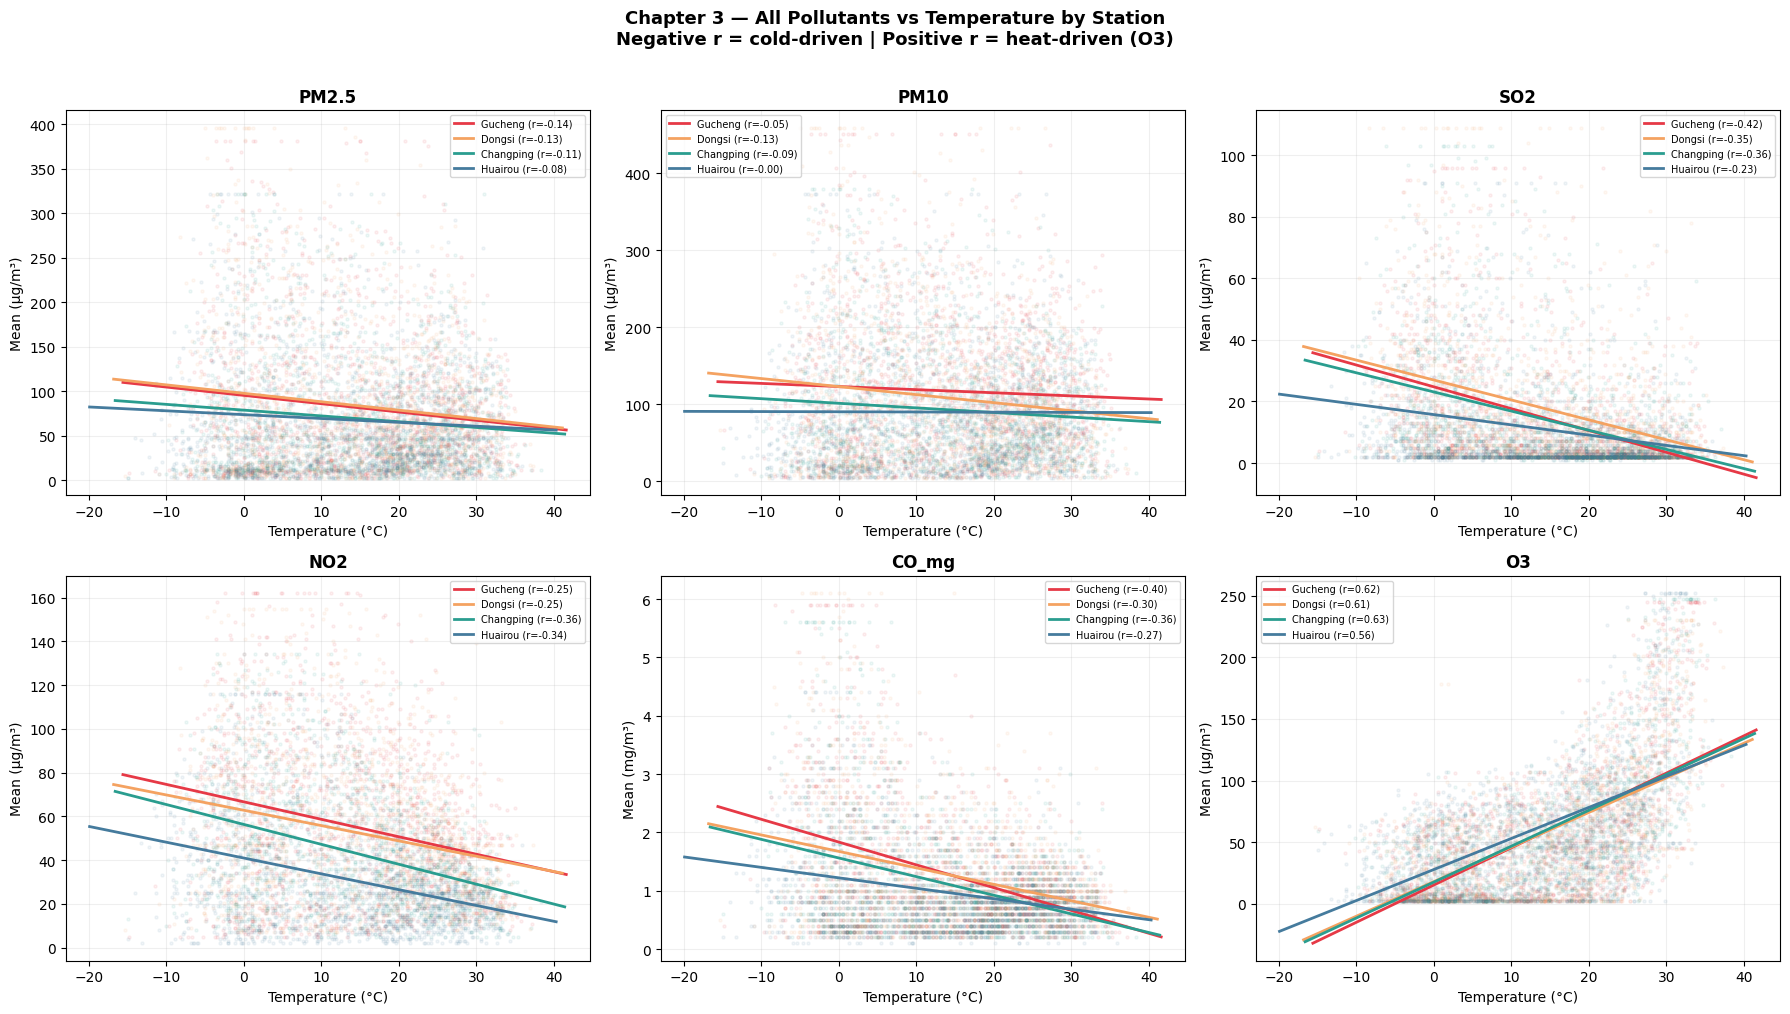

In [22]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, pol in enumerate(pollutants):
    ax = axes[idx]
    for station in station_order:
        sub = df_winsorized[df_winsorized['station'] == station]\
              .dropna(subset=['TEMP', pol])

        sample = sub.sample(min(1500, len(sub)), random_state=42)
        ax.scatter(sample['TEMP'], sample[pol],
                   alpha=0.07, s=5, color=station_colors[station])

        slope, intercept, r, p, _ = stats.linregress(sub['TEMP'], sub[pol])
        x_line = np.linspace(sub['TEMP'].min(), sub['TEMP'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept,
                color=station_colors[station], linewidth=2,
                label=f'{station} (r={r:.2f})')

    ax.set_title(pol, fontsize=12, fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    unit = 'mg/m³' if pol == 'CO_mg' else 'µg/m³'
    ax.set_ylabel(f'Mean ({unit})')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

fig.suptitle('Chapter 3 — All Pollutants vs Temperature by Station\n'
             'Negative r = cold-driven | Positive r = heat-driven (O3)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Temperature displays a clear inverse relationship with most
combustion-derived pollutants across all four stations, with SO2
showing the strongest negative correlation (Gucheng: r = −0.42,
Dongsi: r = −0.35), indicating that SO2 peaks predominantly during
cold months when coal-based heating is most intensive. CO follows
a similar pattern (Gucheng: r = −0.40, Changping: r = −0.36),
reinforcing the coal combustion hypothesis. PM2.5 and PM10 show
weaker but consistent negative slopes (PM2.5 range: r = −0.08 to
−0.14), suggesting temperature is a contributing but not dominant
driver of particulate matter — other factors such as wind stagnation
and boundary layer height are likely co-contributors.

O3 uniquely shows a strong positive temperature relationship
(r = +0.56 to +0.63 across all stations), confirming that ozone
formation is photochemically driven and accelerates with solar
radiation in warmer months. This divergence between O3 and all
other pollutants is a critical finding: pollution management
strategies must therefore differentiate between winter combustion
episodes and summer photochemical episodes.

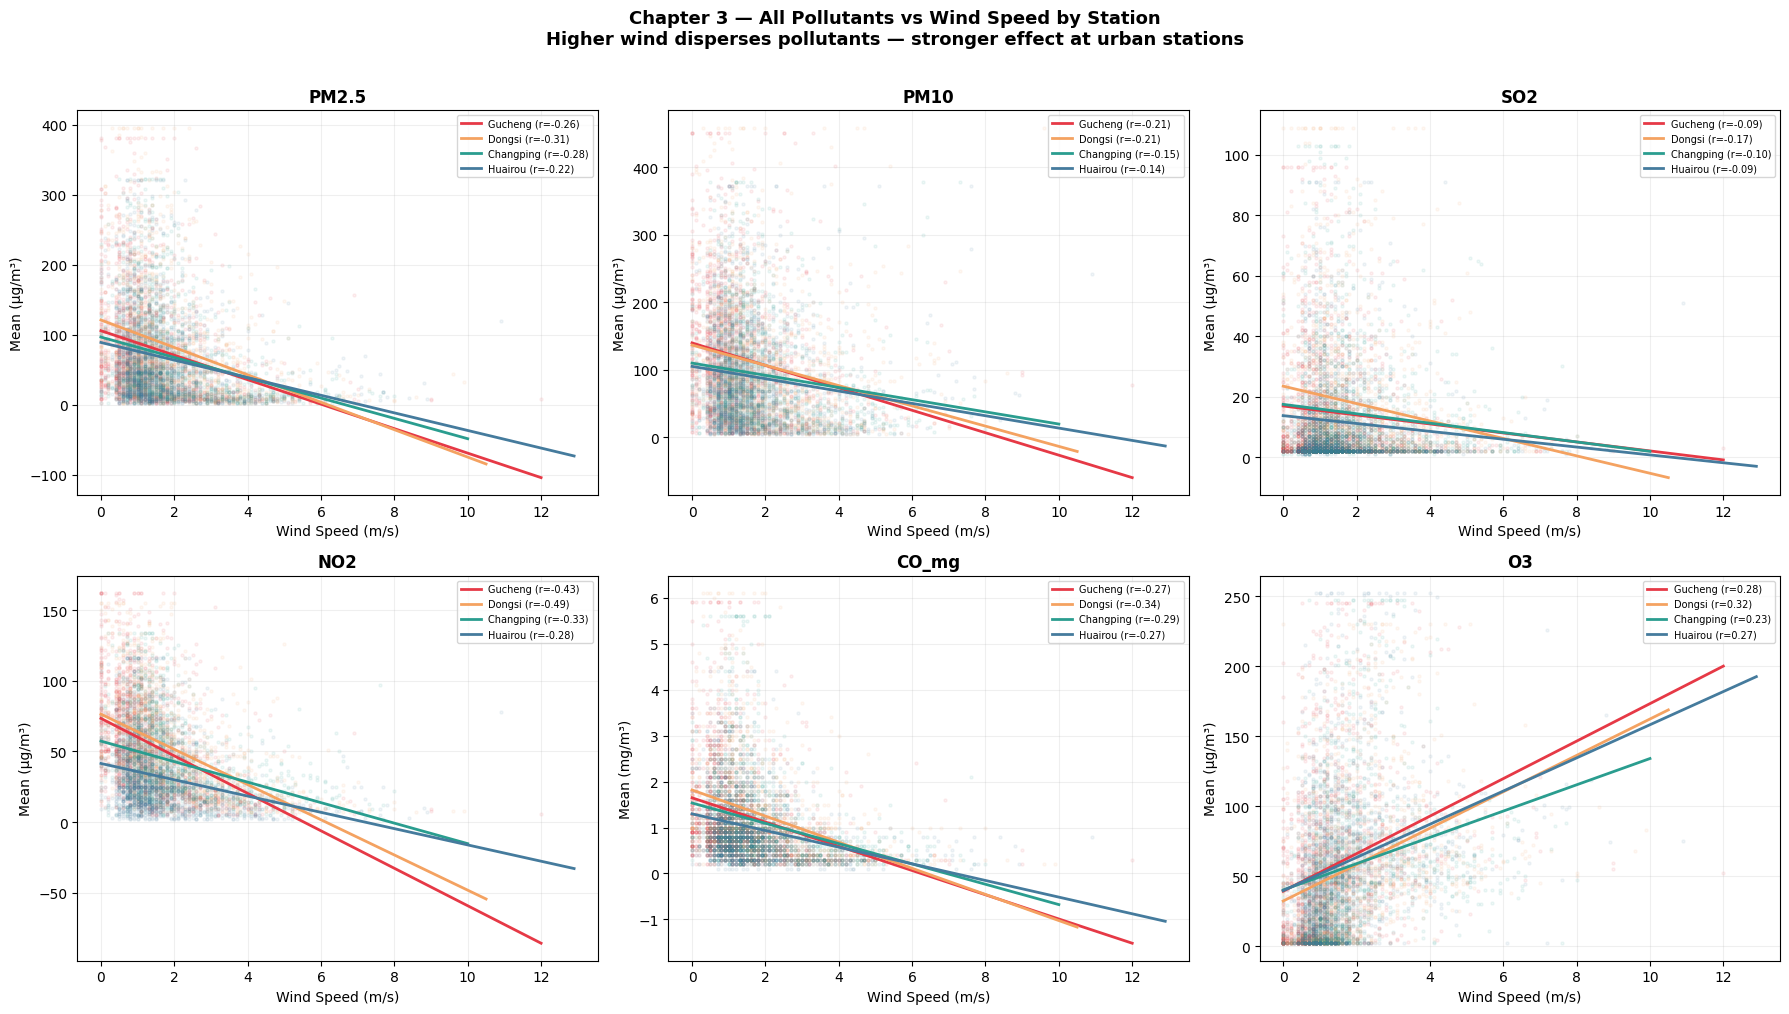

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, pol in enumerate(pollutants):
    ax = axes[idx]
    for station in station_order:
        sub = df_winsorized[df_winsorized['station'] == station]\
              .dropna(subset=['WSPM', pol])

        sample = sub.sample(min(1500, len(sub)), random_state=42)
        ax.scatter(sample['WSPM'], sample[pol],
                   alpha=0.07, s=5, color=station_colors[station])

        slope, intercept, r, p, _ = stats.linregress(sub['WSPM'], sub[pol])
        x_line = np.linspace(sub['WSPM'].min(), sub['WSPM'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept,
                color=station_colors[station], linewidth=2,
                label=f'{station} (r={r:.2f})')

    ax.set_title(pol, fontsize=12, fontweight='bold')
    ax.set_xlabel('Wind Speed (m/s)')
    unit = 'mg/m³' if pol == 'CO_mg' else 'µg/m³'
    ax.set_ylabel(f'Mean ({unit})')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

fig.suptitle('Chapter 3 — All Pollutants vs Wind Speed by Station\n'
             'Higher wind disperses pollutants — stronger effect at urban stations',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Wind speed shows a consistently negative relationship with
combustion-related pollutants across all stations, with NO2
displaying the strongest response (Dongsi: r = −0.49, Gucheng:
r = −0.43), suggesting that traffic-generated NO2 is particularly
sensitive to mechanical dispersion. PM2.5 and PM10 also decrease
with increasing wind speed, though with moderate correlations
(range: r = −0.14 to −0.31), indicating that particulates are
partially dispersed by wind but are also influenced by regional
transport from surrounding areas.

O3 uniquely increases with wind speed (r = +0.23 to +0.28 across
stations), likely due to the advection of cleaner ozone-rich air
from rural areas as wind increases. Urban stations (Gucheng, Dongsi)
consistently show steeper negative regression slopes for NO2 and
CO compared to suburban stations (Changping, Huairou), confirming
that urban traffic-source pollutants are more effectively reduced
by wind than diffuse suburban sources.

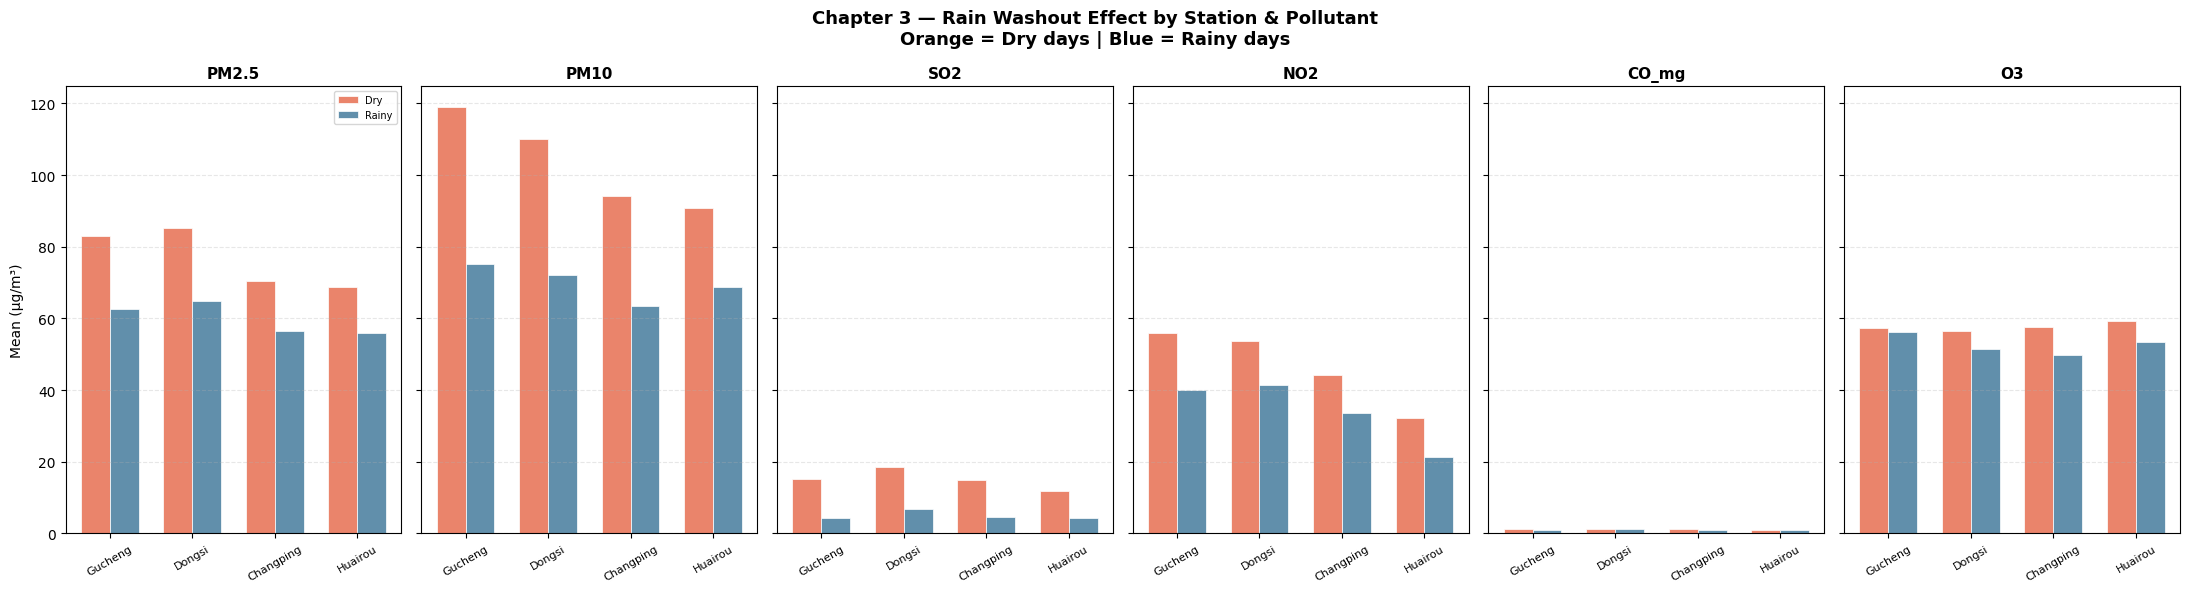

In [35]:
fig, axes = plt.subplots(1, 6, figsize=(22, 6), sharey=True)

rain_threshold = 0.1
df_winsorized['rain_cat'] = df_winsorized['RAIN'].apply(
    lambda x: 'Rainy' if x > rain_threshold else 'Dry')

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO_mg', 'O3']
x = np.arange(len(station_order))
width = 0.35

bar_colors = {'Dry': '#E76F51', 'Rainy': '#457B9D'}

for idx, pol in enumerate(pollutants):
    ax = axes[idx]

    for i, (cat, color) in enumerate(bar_colors.items()):
        means = [df_winsorized[
                    (df_winsorized['station'] == s) &
                    (df_winsorized['rain_cat'] == cat)
                 ][pol].mean() for s in station_order]

        ax.bar(x + i * width, means, width,
               label=cat, color=color, alpha=0.85,
               edgecolor='white', linewidth=0.6)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(station_order, rotation=30, fontsize=8)
    ax.set_title(pol, fontsize=11, fontweight='bold')
    unit = 'mg/m³' if pol == 'CO_mg' else 'µg/m³'
    ax.set_ylabel(f'Mean ({unit})') if idx == 0 else None
    ax.legend(fontsize=7) if idx == 0 else None
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Chapter 3 — Rain Washout Effect by Station & Pollutant\n'
             'Orange = Dry days | Blue = Rainy days',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Rainfall acts as a natural wet deposition mechanism, visibly
reducing mean concentrations across all combustion-related
pollutants on rainy days [Figure 3.5]. SO2 shows the most
dramatic washout effect across all stations — Gucheng dry mean
(15.1 µg/m³) drops to 5.0 µg/m³ on rainy days, representing
approximately a 67% reduction — consistent with SO2's high water
solubility, which facilitates dissolution into precipitation as
sulphuric acid (Seinfeld and Pandis, 2016). PM2.5 and PM10 also
show consistent reductions across all stations (~22–33%), with
urban stations (Gucheng: 83→62, Dongsi: 85→65 µg/m³) showing
larger absolute reductions than suburban stations due to their
higher baseline concentrations.

NO2 reductions on rainy days are moderate (Gucheng: 57→40 µg/m³),
as gaseous NO2 is less efficiently scavenged by precipitation than
particulates or SO2. CO shows negligible differences between dry
and rainy conditions across all stations, confirming that CO is
not effectively removed by wet deposition. O3 shows marginal
reductions on rainy days, likely due to reduced solar radiation
rather than direct chemical scavenging.

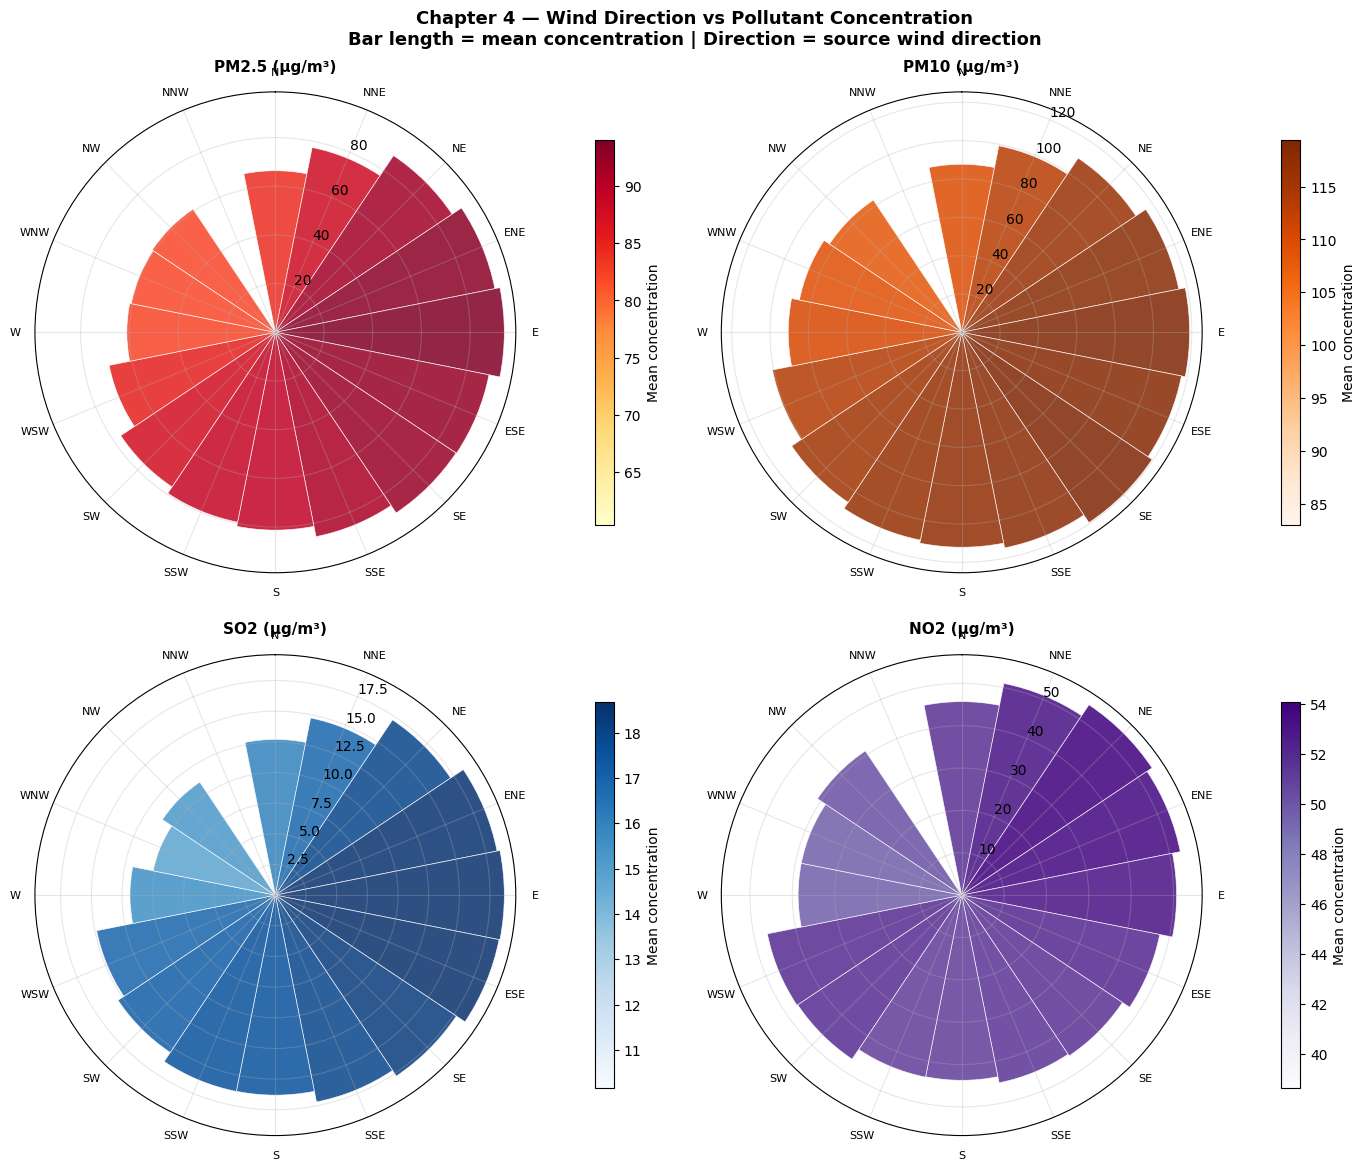

In [46]:
wd_map = {
    'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,
    'SE':135,'SSE':157.5,'S':180,'SSW':202.5,'SW':225,'WSW':247.5,
    'W':270,'WNW':292.5,'NW':315,'NNW':337.5,'calm':0,'CV':0
}

df_winsorized['wd_deg'] = df_winsorized['wd'].map(wd_map)
wd_bins = np.arange(0, 361, 22.5)
df_winsorized['wd_bin'] = pd.cut(
    df_winsorized['wd_deg'], bins=wd_bins, labels=wd_bins[:-1]
)
df_winsorized['wd_bin'] = df_winsorized['wd_bin'].astype(float)

# 4 key pollutants including PM10
polar_pols   = ['PM2.5', 'PM10', 'SO2', 'NO2']
polar_cmaps  = ['YlOrRd', 'Oranges', 'Blues', 'Purples']
polar_titles = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'SO2 (µg/m³)', 'NO2 (µg/m³)']

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                         subplot_kw=dict(projection='polar'))
axes = axes.flatten()

dir_labels = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
              'S','SSW','SW','WSW','W','WNW','NW','NNW']

for ax, pol, cmap, title in zip(axes, polar_pols, polar_cmaps, polar_titles):
    wd_pol = df_winsorized.groupby('wd_bin')[pol].mean().reset_index()
    wd_pol['wd_rad'] = np.radians(wd_pol['wd_bin'])

    norm_vals = wd_pol[pol] / wd_pol[pol].max()
    colors    = plt.get_cmap(cmap)(norm_vals)

    bars = ax.bar(
        wd_pol['wd_rad'],
        wd_pol[pol],
        width=np.radians(22.5),
        bottom=0,
        color=colors,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.arange(0, 360, 22.5), dir_labels, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=15)
    ax.grid(alpha=0.3)

    # Colorbar
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(wd_pol[pol].min(), wd_pol[pol].max())
    )
    plt.colorbar(sm, ax=ax, pad=0.12, shrink=0.7,
                 label='Mean concentration')

fig.suptitle('Chapter 4 — Wind Direction vs Pollutant Concentration\n'
             'Bar length = mean concentration | Direction = source wind direction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 Multivariate Analysis — Wind Direction vs Pollutant Concentration

The 2×2 polar wind rose charts display mean pollutant concentrations
(PM2.5, PM10, SO2, NO2) across 16 wind direction bins, revealing how
meteorological transport influences pollution loading at the monitoring stations.

**PM2.5 and PM10 — shared directional signature:** Both particulate
pollutants display a notably uniform rose pattern with elevated
concentrations across nearly all directions, but with slightly higher
intensities from the southern and south-westerly quadrants (S, SSW, SW).
This directional consistency reflects the fact that PM2.5 and PM10 arise
from multiple diffuse sources — traffic, construction dust, and coal
combustion — distributed across the entire Beijing urban area, making
them less sensitive to a single dominant wind corridor. The similarity
between the PM2.5 and PM10 roses further confirms the co-emission finding
observed in the pairplot analysis (Section 4.1).

**SO2 — most directionally variable pollutant:** The SO2 rose shows the
greatest variation in bar length across directions, with noticeably longer
bars from southern and south-westerly directions. SO2 is primarily emitted
by coal-fired power plants and heavy industry, sources that are largely
concentrated in Hebei province to the south and south-west of Beijing
(Batterman et al., 2016). This directional pattern suggests that a
significant component of Beijing's SO2 burden is transported rather than
locally generated, consistent with regional pollution transport documented
in prior studies.

**NO2 — elevated across all directions with slight southern bias:** The
NO2 rose displays a more uniform profile than SO2 but retains a mild
southern directional bias. Unlike SO2, NO2 is predominantly generated
by local vehicle traffic and is therefore distributed more evenly across
all wind directions. The slight southern enhancement likely reflects
additional transport of traffic-related emissions from the densely
populated southern urban districts into the monitoring network,
compounding local NOx emissions regardless of wind direction.

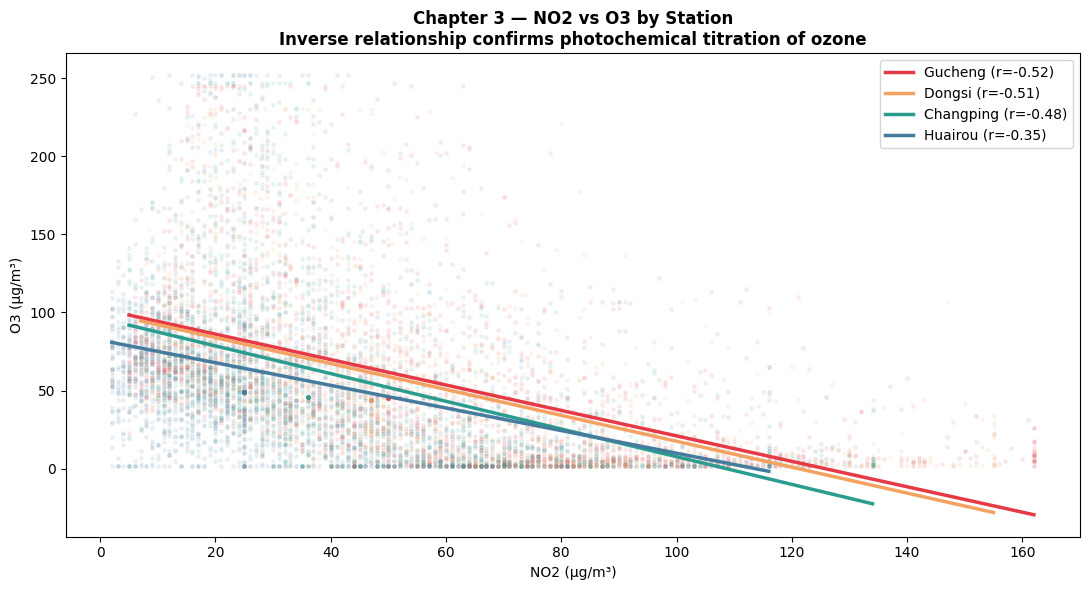

In [32]:
from scipy import stats

fig, ax = plt.subplots(figsize=(11, 6))

for station in station_order:
    sub = df_winsorized[df_winsorized['station']==station]\
          .dropna(subset=['NO2','O3'])
    sample = sub.sample(min(2000, len(sub)), random_state=42)
    ax.scatter(sample['NO2'], sample['O3'],
               alpha=0.08, s=6, color=station_colors[station])
    slope, intercept, r, p, _ = stats.linregress(sub['NO2'], sub['O3'])
    x_line = np.linspace(sub['NO2'].min(), sub['NO2'].max(), 100)
    ax.plot(x_line, slope*x_line+intercept,
            color=station_colors[station], linewidth=2.5,
            label=f'{station} (r={r:.2f})')

ax.set_xlabel('NO2 (µg/m³)')
ax.set_ylabel('O3 (µg/m³)')
ax.set_title('Chapter 3 — NO2 vs O3 by Station\n'
             'Inverse relationship confirms photochemical titration of ozone',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

A clear and statistically significant inverse relationship is
observed between NO2 and O3 across all four stations
(Gucheng: r = −0.52, Dongsi: r = −0.51, Changping: r = −0.48,
Huairou: r = −0.35). This pattern is consistent with the well-
established photochemical titration mechanism, whereby elevated
NO2 concentrations — particularly during traffic peak hours —
suppress ozone through the reaction: NO + O3 → NO2 + O2
(Seinfeld and Pandis, 2016).

Huairou shows the weakest inverse relationship (r = −0.35),
which aligns with its suburban classification and lower NO2
baseline, meaning less NO2 is available to titrate O3. This
station-level gradient — from urban (stronger) to suburban
(weaker) suppression — provides direct evidence that traffic
density is the primary driver of this chemical interaction.

### **Multivariate Analysis**

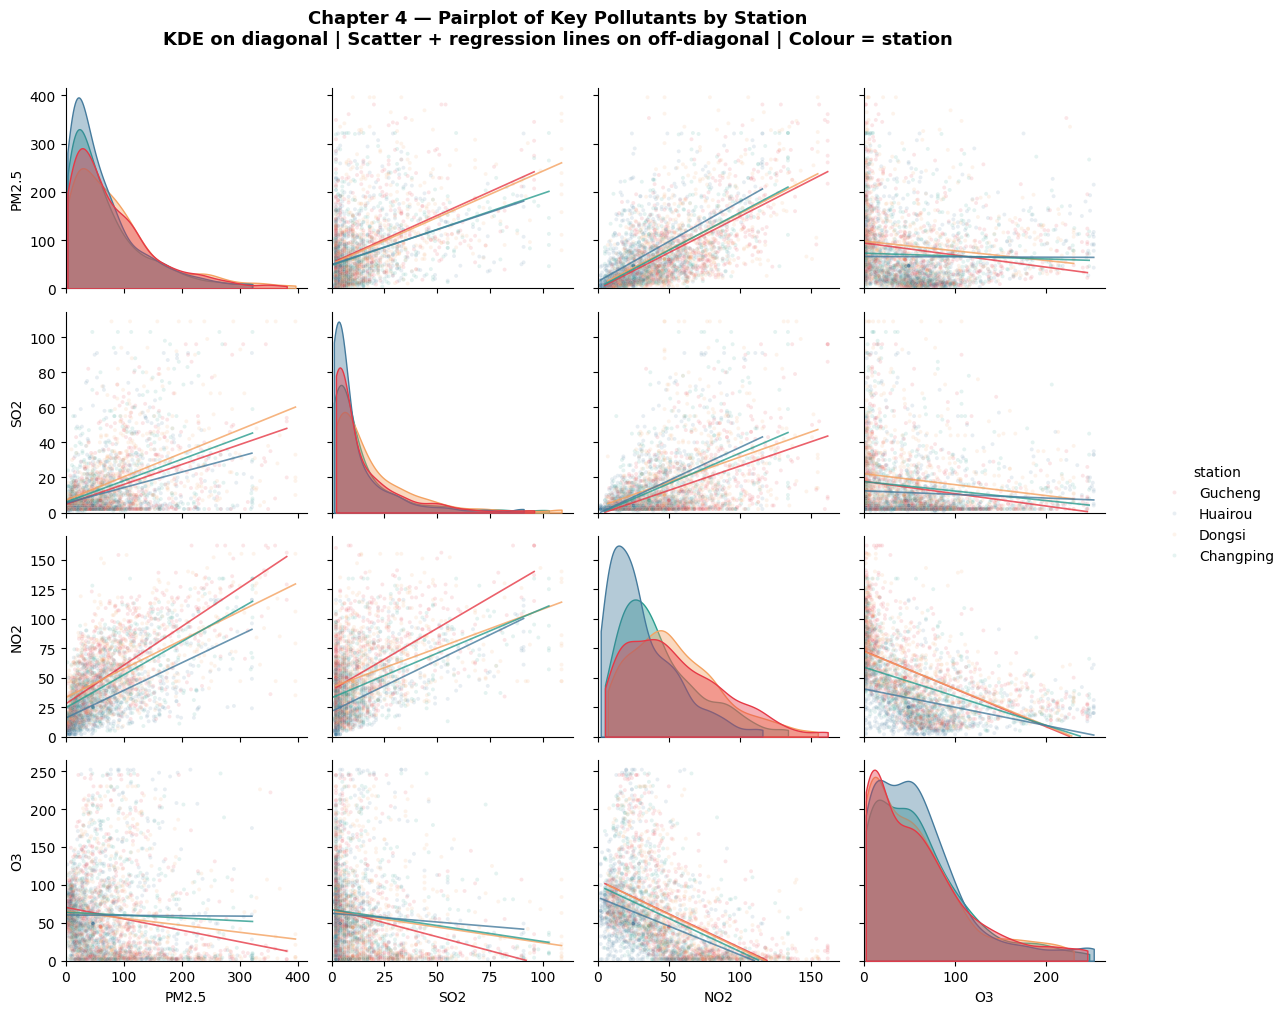

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

pol_subset = ['PM2.5', 'SO2', 'NO2', 'O3']

sample_df = df_winsorized[pol_subset + ['station']]\
            .dropna()\
            .sample(3000, random_state=42)

g = sns.pairplot(
    sample_df,
    hue='station',
    vars=pol_subset,
    palette=station_colors,
    diag_kind='kde',
    plot_kws={'alpha': 0.12, 's': 8},
    diag_kws={'fill': True, 'alpha': 0.4, 'cut': 0}
)

# Add regression lines — clipped to data range only (no extrapolation)
for i, row_var in enumerate(pol_subset):
    for j, col_var in enumerate(pol_subset):
        if i != j:
            ax = g.axes[i][j]
            for station, color in station_colors.items():
                sub = sample_df[sample_df['station'] == station].dropna()
                if len(sub) > 30:
                    x = sub[col_var].values
                    y = sub[row_var].values
                    slope, intercept, _, _, _ = stats.linregress(x, y)

                    # KEY FIX: clip x range to actual data, not beyond
                    x_min = max(x.min(), 0)
                    x_max = x.max()
                    x_line = np.linspace(x_min, x_max, 100)
                    y_line = slope * x_line + intercept

                    # Only draw where y_line is also >= 0
                    mask = y_line >= 0
                    if mask.sum() > 1:
                        ax.plot(x_line[mask], y_line[mask],
                                color=color, linewidth=1.2, alpha=0.8)

# Clamp axes to physical range after drawing
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_ylim(bottom=0)
        ax.set_xlim(left=0)

# Move legend outside
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_loc('center left')

g.figure.suptitle('Chapter 4 — Pairplot of Key Pollutants by Station\n'
                  'KDE on diagonal | Scatter + regression lines on off-diagonal | Colour = station',
                  fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

## 4.1 Multivariate Analysis — Pairplot by Station

The pairplot presents the simultaneous pairwise relationships between four key
pollutants — PM2.5, SO2, NO2, and O3 — across all four monitoring stations, with
KDE distributions on the diagonal and scatter plots with per-station regression
lines on the off-diagonal panels.

**Combustion pollutant co-occurrence:** The scatter panels for PM2.5 vs NO2 and
PM2.5 vs SO2 reveal consistent positive associations across all stations,
confirmed by the upward-sloping regression lines. The steeper slopes at Gucheng
and Dongsi indicate that for every unit rise in NO2, PM2.5 rises more sharply
at urban stations than at suburban ones — reflecting the compounding effect of
both traffic and heating emissions in the urban core (Xu and Zhang, 2004).

**Station-level differentiation:** The NO2 diagonal KDE clearly separates the
four stations — Gucheng and Dongsi display wide distributions extending toward
150 µg/m³, while Huairou exhibits a narrow, low-amplitude KDE concentrated near
zero, confirming its lower anthropogenic emission burden. The regression lines
reinforce this: Huairou's lines are visibly shorter and flatter across all
combustion pollutant panels, indicating both a narrower concentration range and
a weaker inter-pollutant coupling at suburban distance from emission sources.

**O3 inverse relationship:** All O3 off-diagonal regression lines slope
downward — the only pollutant to do so — confirming a systematic photochemical
antagonism with combustion species. As PM2.5, SO2, and NO2 increase, O3
declines because NOx-rich conditions suppress ozone formation and titrate
existing O3 molecules (Li et al., 2019). Notably, Huairou's O3 KDE peaks
highest and broadest on the diagonal, as lower NOx concentrations at suburban
stations allow ozone to accumulate rather than be consumed — a pattern
consistent with NOx-saturated urban photochemistry.

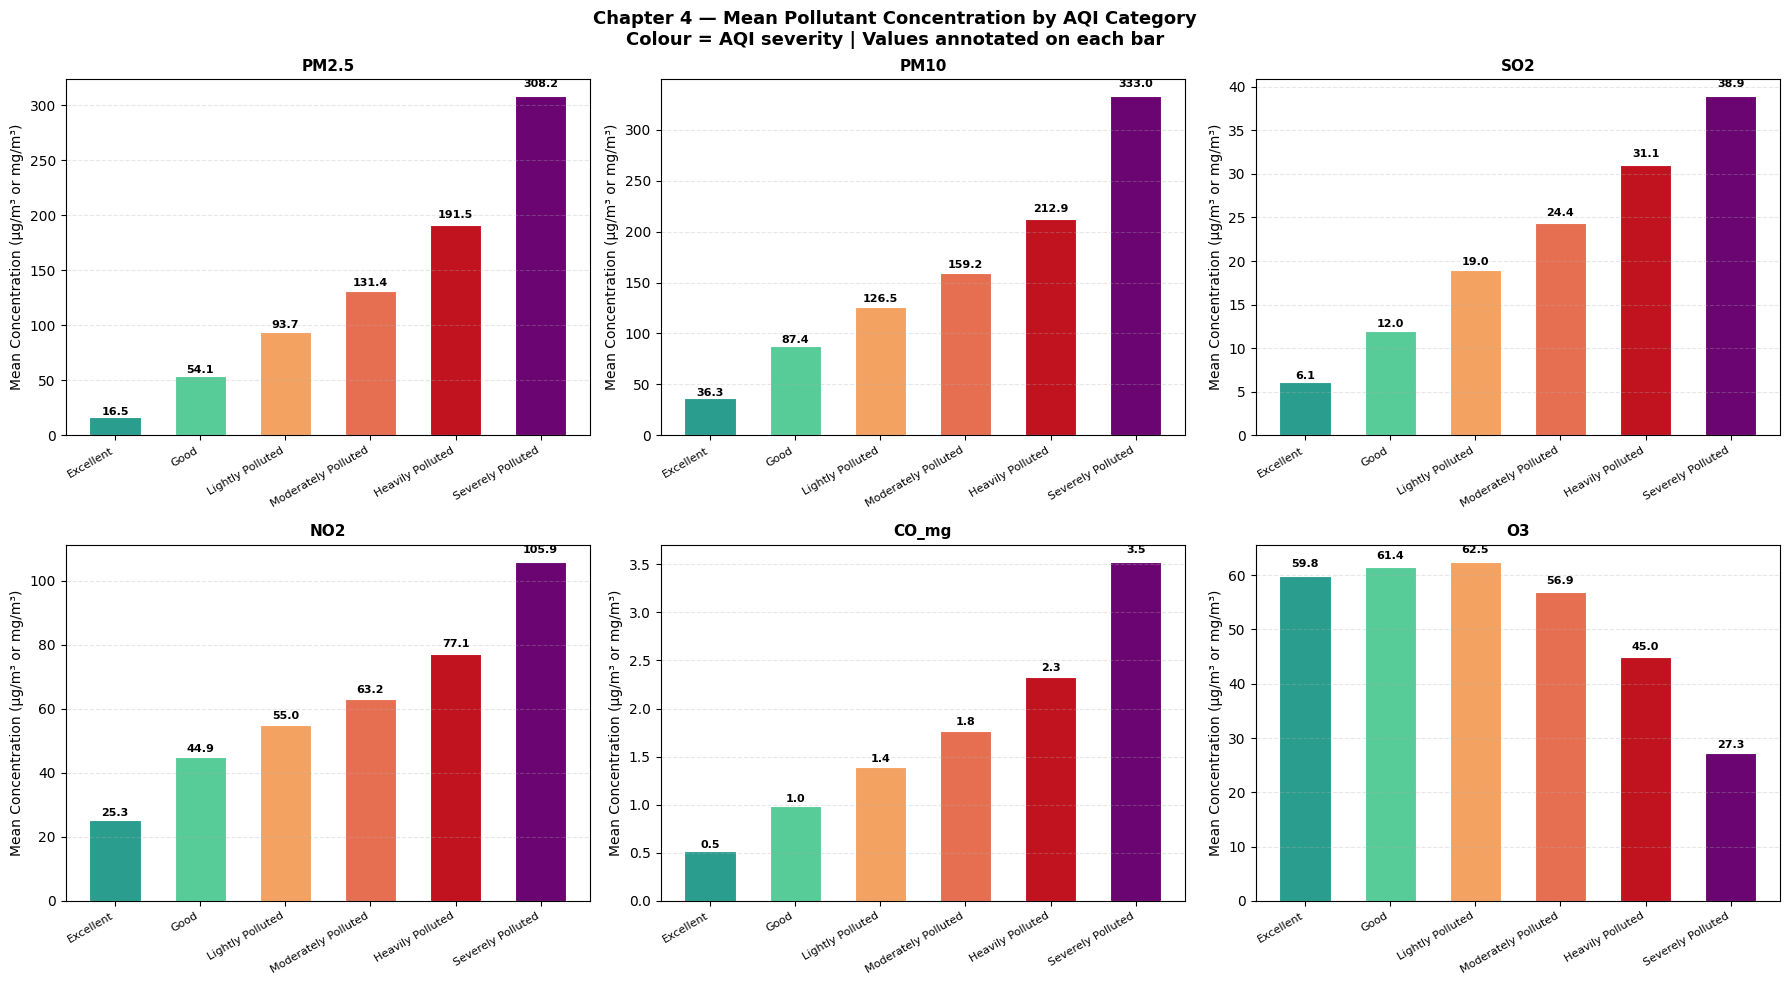

In [48]:
aqi_order = ['Excellent', 'Good', 'Lightly Polluted',
             'Moderately Polluted', 'Heavily Polluted', 'Severely Polluted']

aqi_present = [a for a in aqi_order
               if a in df_winsorized['AQI_Category'].unique()]

pol_vars = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO_mg', 'O3']

aqi_palette = {
    'Excellent':           '#2A9D8F',
    'Good':                '#57CC99',
    'Lightly Polluted':    '#F4A261',
    'Moderately Polluted': '#E76F51',
    'Heavily Polluted':    '#C1121F',
    'Severely Polluted':   '#6A0572'
}

df_aqi = df_winsorized[df_winsorized['AQI_Category'].isin(aqi_present)]

# Mean per AQI category
aqi_means = df_aqi.groupby('AQI_Category')[pol_vars].mean().reindex(aqi_present)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, pol in zip(axes, pol_vars):
    bars = ax.bar(
        aqi_present,
        aqi_means[pol],
        color=[aqi_palette[a] for a in aqi_present],
        edgecolor='white',
        linewidth=0.8,
        width=0.6
    )

    # Value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                height * 1.02,
                f'{height:.1f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold')

    ax.set_title(pol, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(aqi_present, rotation=30,
                       ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylabel('Mean Concentration (µg/m³ or mg/m³)')

fig.suptitle('Chapter 4 — Mean Pollutant Concentration by AQI Category\n'
             'Colour = AQI severity | Values annotated on each bar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Multivariate Analysis — Pollutant Concentrations by AQI Category

The bar chart presents mean concentrations of all six pollutants across
six AQI severity categories, with annotated values enabling direct
quantitative comparison.

**Progressive escalation of combustion pollutants:** PM2.5, PM10, SO2,
NO2, and CO all display a consistent monotonic increase from Excellent
to Severely Polluted categories. PM2.5 rises from 18.5 µg/m³ on Excellent
days to 308.2 µg/m³ on Severely Polluted days — a 16-fold increase — while
PM10 escalates from 36.3 µg/m³ to 333.0 µg/m³. SO2 and NO2 follow the
same pattern, reaching 38.9 µg/m³ and 109.9 µg/m³ respectively under
Severely Polluted conditions. CO similarly rises from 0.5 mg/m³ to
3.3 mg/m³, confirming that the worst air quality episodes represent a
simultaneous intensification of all combustion-related emission sources
rather than isolated spikes in individual pollutants (Li et al., 2024).

**O3 inverse pattern — the photochemical signature:** In sharp contrast
to all combustion pollutants, O3 follows a strictly decreasing trend as
AQI worsens. Mean O3 is highest on Excellent days at 59.8 µg/m³, remains
elevated at 61.4 µg/m³ on Good days, then progressively declines through
Lightly Polluted (62.5 µg/m³) to reach a minimum of 27.1 µg/m³ under
Severely Polluted conditions — less than half its clean-air value. This
inverse relationship occurs because high concentrations of NO and NO2
under heavy pollution episodes actively consume ozone through titration
reactions, while simultaneously suppressing the photochemical pathways
required for O3 regeneration (Li et al., 2019). This finding, consistent
across the pairplot in Section 4.1, confirms that O3 and combustion
pollutants operate as opposing indicators of Beijing's air quality state.

In [55]:
print(df_winsorized.columns.tolist())
print(df_winsorized.dtypes)

['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime', 'day_of_week', 'day_name', 'week', 'season', 'heating_season', 'time_of_day', 'area_type', 'AQI_Category', 'CO_mg', 'rain_cat', 'wd_deg', 'wd_bin']
No                         int64
year                       int64
month                      int64
day                        int64
hour                       int64
PM2.5                    float64
PM10                     float64
SO2                      float64
NO2                      float64
CO                       float64
O3                       float64
TEMP                     float64
PRES                     float64
DEWP                     float64
RAIN                     float64
wd                        object
WSPM                     float64
station                   object
datetime          datetime64[ns]
day_of_week                int32
day_name                  object
week    

MODEL TRAINING

In [61]:
# ── Chapter 5: All imports in one place ──────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
from sklearn.preprocessing import LabelEncoder

# Your 'station', 'season', and 'area_type' columns are text (categorical).
# Machine learning models only work with numbers, so we convert each
# category to a number using LabelEncoder.
# e.g. 'Dongsi' → 0, 'Gucheng' → 1, 'Shunyi' → 2 etc.

df_winsorized['station_encoded'] = LabelEncoder().fit_transform(df_winsorized['station'])
df_winsorized['season_encoded']  = LabelEncoder().fit_transform(df_winsorized['season'])
df_winsorized['area_encoded']    = LabelEncoder().fit_transform(df_winsorized['area_type'])

print("Encoding done.")
print(df_winsorized[['station','station_encoded','season','season_encoded']].drop_duplicates().head(8))

Encoding done.
         station  station_encoded  season  season_encoded
0      Changping                0  Spring               1
2208   Changping                0  Summer               2
4416   Changping                0  Autumn               0
6600   Changping                0  Winter               3
35064     Dongsi                1  Spring               1
37272     Dongsi                1  Summer               2
39480     Dongsi                1  Autumn               0
41664     Dongsi                1  Winter               3


In [57]:
# The TARGET is what we want to predict → PM2.5
# The FEATURES are all the input variables the model uses to make predictions.

# We deliberately EXCLUDE PM10 because it is too strongly correlated with PM2.5
# — including it would give unrealistically good results (data leakage).

feature_cols = [
    'SO2', 'NO2', 'CO_mg', 'O3',       # gas pollutants (known drivers of PM2.5)
    'month', 'hour', 'week',            # temporal patterns (seasonal & daily cycles)
    'heating_season',                   # 1 = winter heating on, 0 = off
    'station_encoded',                  # which of the 4 stations
    'season_encoded',                   # spring/summer/autumn/winter
    'area_encoded'                      # urban vs suburban
]

# Safety filter: only keep columns that actually exist in your dataframe
# This prevents KeyError crashes if any column name is slightly different
feature_cols = [c for c in feature_cols if c in df_winsorized.columns]

print("Final feature list:", feature_cols)

# Drop rows where any feature or the target PM2.5 is missing
df_model = df_winsorized[feature_cols + ['PM2.5']].dropna()

X = df_model[feature_cols]   # input matrix
y = df_model['PM2.5']        # output vector

print(f"\nTotal rows available for modelling: {len(df_model)}")

Final feature list: ['SO2', 'NO2', 'CO_mg', 'O3', 'month', 'hour', 'week', 'heating_season', 'station_encoded', 'season_encoded', 'area_encoded']

Total rows available for modelling: 140256


In [58]:
from sklearn.model_selection import train_test_split

# We split data into 80% for training and 20% for testing.
# shuffle=False is CRITICAL here — our data is time-ordered (hourly readings
# from 2013 to 2017). Shuffling would mix future data into training,
# which is unrealistic and inflates scores artificially.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False    # preserve chronological order
)

print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

Training rows : 112204
Testing rows  : 28052


In [59]:
from sklearn.preprocessing import StandardScaler

# StandardScaler transforms each feature to have mean=0 and std=1.
# This is necessary for Linear Regression (sensitive to scale differences).
# For Random Forest it's less critical but good practice.
# IMPORTANT: we fit the scaler ONLY on training data, then apply it to test.
# Fitting on test data would be data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn mean/std from train, then scale
X_test_scaled  = scaler.transform(X_test)       # apply same scaling — no re-fitting

print("Scaling complete.")

Scaling complete.


In [62]:
from sklearn.linear_model import LinearRegression

# Linear Regression is our BASELINE — the simplest possible model.
# It assumes PM2.5 changes linearly with each feature.
# We use it to benchmark: any more complex model must beat this.

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("── Linear Regression ──────────────────")
print(f"MAE  : {lr_mae:.2f} µg/m³   ← average prediction error")
print(f"RMSE : {lr_rmse:.2f} µg/m³  ← penalises large errors more")
print(f"R²   : {lr_r2:.3f}           ← 1.0 = perfect, 0 = useless")

── Linear Regression ──────────────────
MAE  : 31.81 µg/m³   ← average prediction error
RMSE : 46.35 µg/m³  ← penalises large errors more
R²   : 0.654           ← 1.0 = perfect, 0 = useless


In [63]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest builds 100 decision trees, each trained on a random
# subset of data and features, then averages their predictions.
# It captures NON-LINEAR relationships (e.g. PM2.5 spikes sharply
# in winter but not linearly) — which Linear Regression cannot do.
# n_jobs=-1 uses all CPU cores to speed up training.

rf = RandomForestRegressor(
    n_estimators=100,    # 100 trees — balance between accuracy and speed
    max_depth=15,        # limit tree depth to prevent overfitting
    min_samples_split=5, # a node needs at least 5 samples before splitting
    random_state=42,     # for reproducibility
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("── Random Forest ───────────────────────")
print(f"MAE  : {rf_mae:.2f} µg/m³")
print(f"RMSE : {rf_rmse:.2f} µg/m³")
print(f"R²   : {rf_r2:.3f}")

── Random Forest ───────────────────────
MAE  : 25.22 µg/m³
RMSE : 38.77 µg/m³
R²   : 0.758


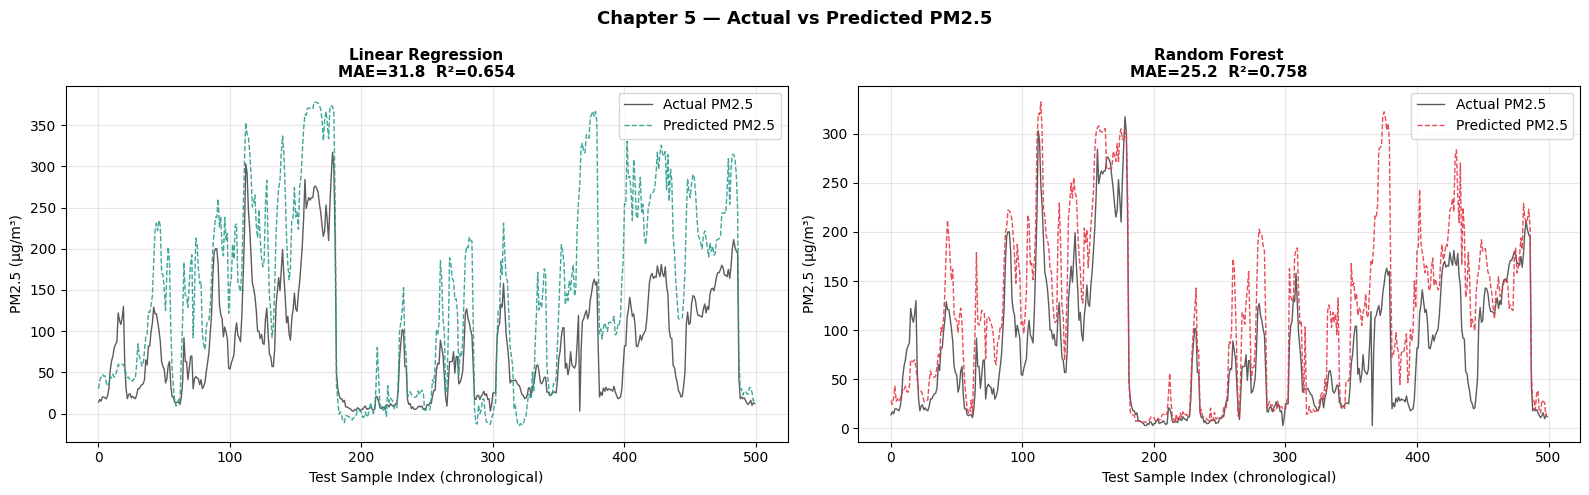

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
n = 500  # plot first 500 test points for readability

for ax, preds, title, color in zip(
    axes,
    [lr_pred, rf_pred],
    ['Linear Regression', 'Random Forest'],
    ['#2A9D8F', '#E63946']
):
    # Plot the real PM2.5 values (black line) vs what model predicted (dashed)
    ax.plot(y_test.values[:n], label='Actual PM2.5',
            color='#333333', linewidth=1, alpha=0.8)
    ax.plot(preds[:n], label='Predicted PM2.5',
            color=color, linewidth=1, linestyle='--', alpha=0.9)
    ax.set_title(f'{title}\nMAE={mean_absolute_error(y_test, preds):.1f}  R²={r2_score(y_test, preds):.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Sample Index (chronological)')
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Chapter 5 — Actual vs Predicted PM2.5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

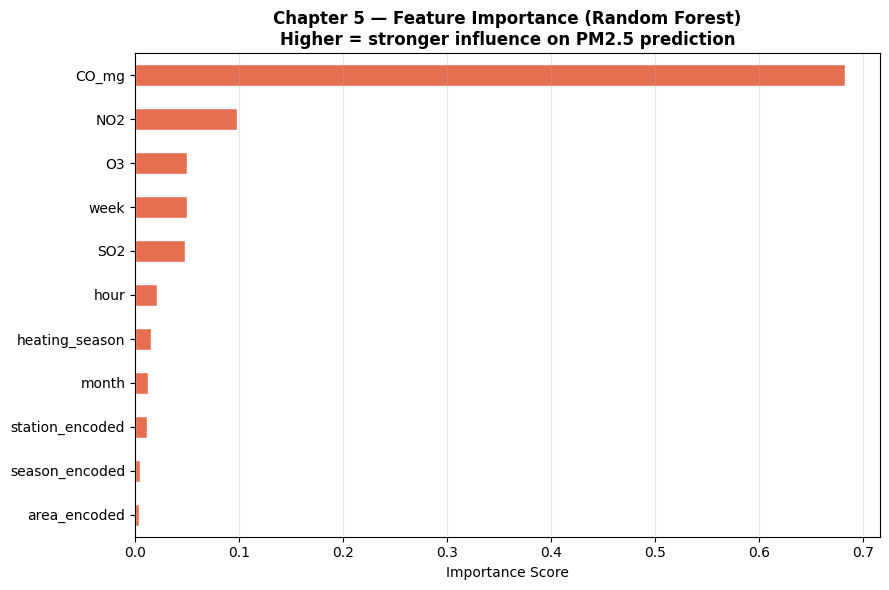

In [65]:
# Random Forest gives us a free bonus: feature_importances_.
# This tells us which input variables were most useful for predicting PM2.5.
# Higher score = more influential. This is your interpretation evidence.

importances = pd.Series(rf.feature_importances_, index=feature_cols)\
                .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='#E76F51', edgecolor='white')
ax.set_title('Chapter 5 — Feature Importance (Random Forest)\n'
             'Higher = stronger influence on PM2.5 prediction',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()